# Ookla EDA — Myanmar Fixed Broadband & Mobile/Cellular (Combined)

Same structure/methodology as the Thailand combined notebook. Shared setup (geo, province/region reference, GDP/tier context) runs once; Part 1 and Part 2 each run an independent full EDA pass over their own dataset (fixed vs mobile Ookla tiles).

**Data sources:** ADM1 boundaries from geoBoundaries (simplified); population/area/density from public sources (Wikipedia); no province-level GDP is published, so national GDP is repeated across states/regions (Naypyidaw's 2014 pop/area is folded into Mandalay Region -- geoBoundaries ADM1 does not carve it out separately); compiled into `data/reference/myanmar_reference.csv`. GDP unit: nominal USD, 2021 (World Bank), PPP-adjusted and THB columns derived from it -- see CSV header comment.

Run All top-to-bottom to generate outputs.


### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="../../data/ookla/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
    THAILAND_GEOJSON = '../../data/geo/myanmar_provinces.geojson'

    PROVINCE_COL = 'name' 

    perf_tiles_url = "../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

    thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

    # Capture the total bounds of Myanmar's boundaries for the bounding box filter
    state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

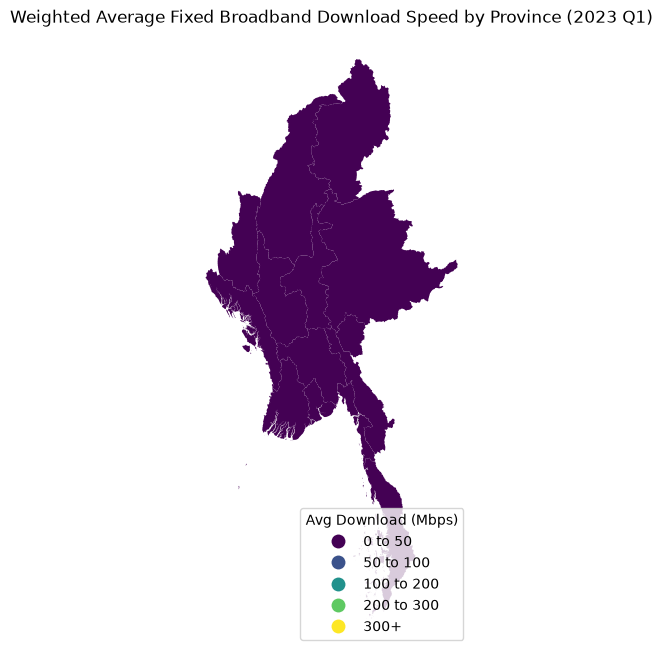

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()

plt.savefig(f'../../outputs/ookla/myanmar/08_province_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import os

file_path = "../../data/ookla/raw"
files = sorted([f for f in os.listdir(file_path) if f.endswith('.parquet')])
print(f"{len(files)} files, reading first for inspection...")

# Read single file to inspect schema — avoid loading 3.7GB at once
df = pd.read_parquet(os.path.join(file_path, files[0]), engine='pyarrow')

23 files, reading first for inspection...


In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


## Province Reference Data

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/myanmar_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 14
Regions: ['Central Dry Zone', 'Eastern Highlands', 'Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands']

province_en                        region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
 Ayeyarwady Lower Myanmar / Delta-Coastal   6184829              177                 165710.4              1
       Chin  Northern / Western Highlands    478801               13                 165710.4              4
    Saigang              Central Dry Zone   5325347               57                 165710.4              3
     Kachin  Northern / Western Highlands   1689441               19                 165710.4              4
      Kayah             Eastern Highlands    286627               24                 165710.4              4
      Kayin Lower Myanmar / Delta-Coastal   1574079               52                 165710.4              3
     Magway              Central Dry Zone   3917055               87                 165710.4      

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                               provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                                      
Central Dry Zone                       3        16.57        102.0             165710.0             165710.0
Eastern Highlands                      2         6.11         30.0             165710.0             165710.0
Lower Myanmar / Delta-Coastal          6        23.45        211.0             165710.0             165710.0
Northern / Western Highlands           3         5.36         40.0             165710.0             165710.0


### GDP per Capita vs Population Density — by Region

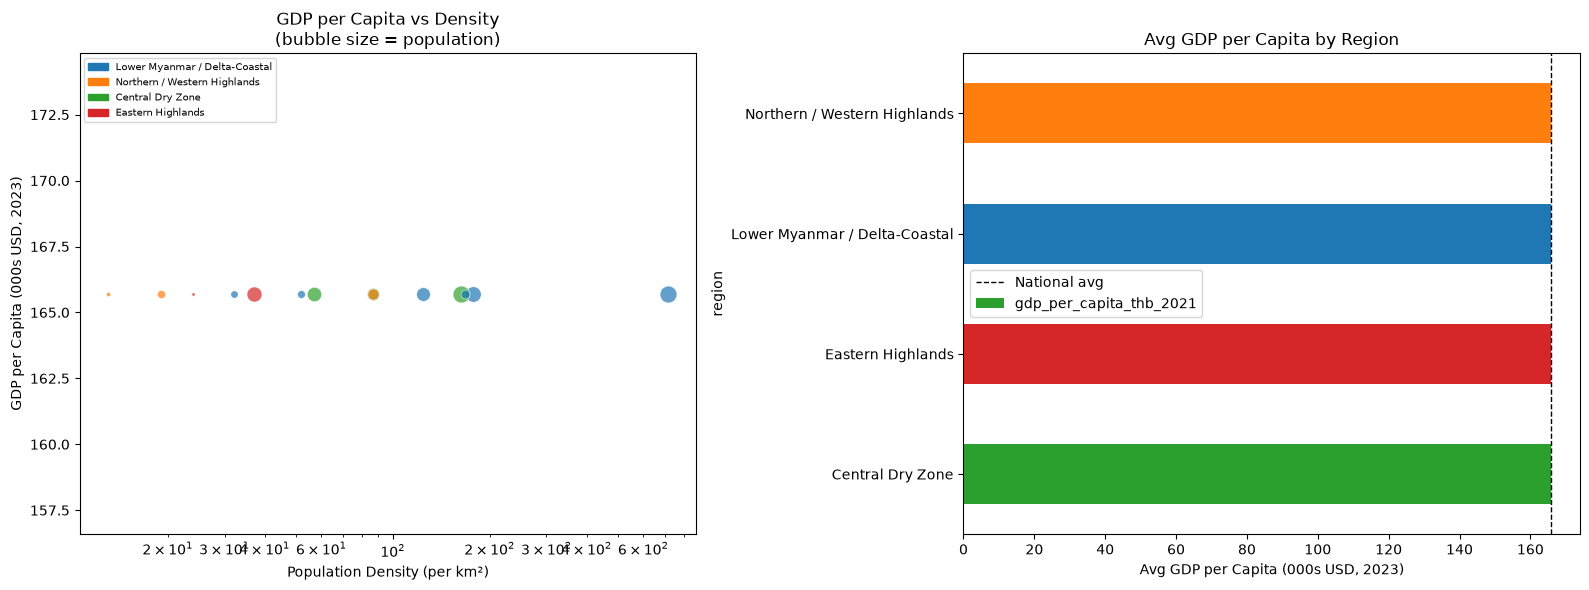

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

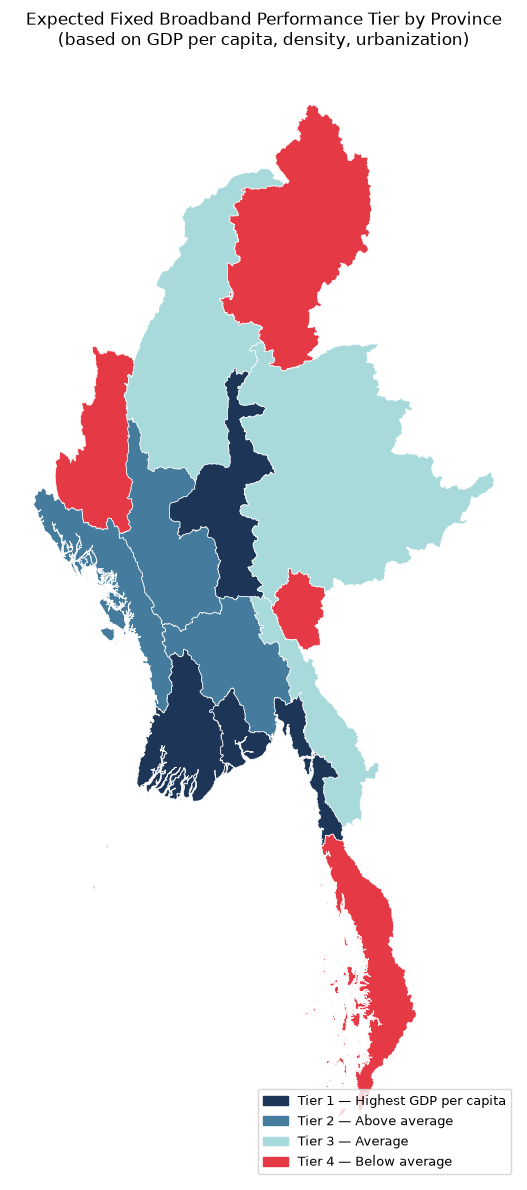

In [18]:
THAILAND_GEOJSON = '../../data/geo/myanmar_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
province_en                        region  pop_2024  gdp_per_capita_thb_2021  internet_tier
 Ayeyarwady Lower Myanmar / Delta-Coastal   6184829                 165710.4              1
       Chin  Northern / Western Highlands    478801                 165710.4              4
    Saigang              Central Dry Zone   5325347                 165710.4              3
     Kachin  Northern / Western Highlands   1689441                 165710.4              4
      Kayah             Eastern Highlands    286627                 165710.4              4
      Kayin Lower Myanmar / Delta-Coastal   1574079                 165710.4              3
     Magway              Central Dry Zone   3917055                 165710.4              2
   Mandalay              Central Dry Zone   7325965                 165710.4              1
        Mon Lower Myanmar / Delta-Coastal   2054393                 165710.4              1
    Rakhine  Northern / Western Highlands   318

---
# Part 1 — Fixed Broadband


## Full EDA — Ookla Fixed Broadband, Myanmar (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/myanmar_provinces.geojson'
PROV_REF    = '../../data/reference/myanmar_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*fixed_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   72,185 raw tiles → 14 provinces


  2023-Q2 (2023-04-01):   71,125 raw tiles → 14 provinces


  2023-Q3 (2023-07-01):   73,546 raw tiles → 14 provinces


  2023-Q4 (2023-10-01):   75,803 raw tiles → 14 provinces


  2024-Q1 (2024-01-01):   74,773 raw tiles → 14 provinces


...

  2024-Q3 (2024-07-01):   69,219 raw tiles → 14 provinces


  2024-Q4 (2024-10-01):   64,710 raw tiles → 14 provinces


  2025-Q1 (2025-01-01):   63,584 raw tiles → 14 provinces


  2025-Q2 (2025-04-01):   69,567 raw tiles → 14 provinces


  2025-Q4 (2025-10-01):   71,267 raw tiles → 14 provinces

Master shape: (154, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  14

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


In [21]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    14
2023-Q2    14
2023-Q3    14
2023-Q4    14
2024-Q1    13
2024-Q2    13
2024-Q3    14
2024-Q4    12
2025-Q1    10
2025-Q2    10
2025-Q4    11

Overall reliable: 139 / 154 (90.3%)


### 2. Data Quality — Coverage per Province

In [22]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 154 | Actual: 154 | Missing: 0

All 154 provinces covered in every quarter.

Low-test quarters (< 100 tests) — 15 cases:
      name   label  total_tests  n_tiles
Ayeyarwady 2025-Q4         15.0      7.0
Ayeyarwady 2024-Q4         21.0     18.0
Ayeyarwady 2025-Q2         31.0     15.0
     Kayah 2024-Q2         39.0     17.0
   Rakhine 2025-Q1         45.0     25.0
   Rakhine 2025-Q4         58.0     20.0
Ayeyarwady 2025-Q1         59.0     28.0
      Bago 2025-Q1         71.0     34.0
       Mon 2025-Q2         74.0     33.0
      Bago 2025-Q4         77.0     36.0
   Rakhine 2024-Q4         78.0     25.0
     Kayah 2025-Q2         83.0     28.0
Tanitharyi 2025-Q1         89.0     35.0
   Rakhine 2025-Q2         92.0     29.0
     Kayah 2024-Q1         95.0     12.0


In [23]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 139 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

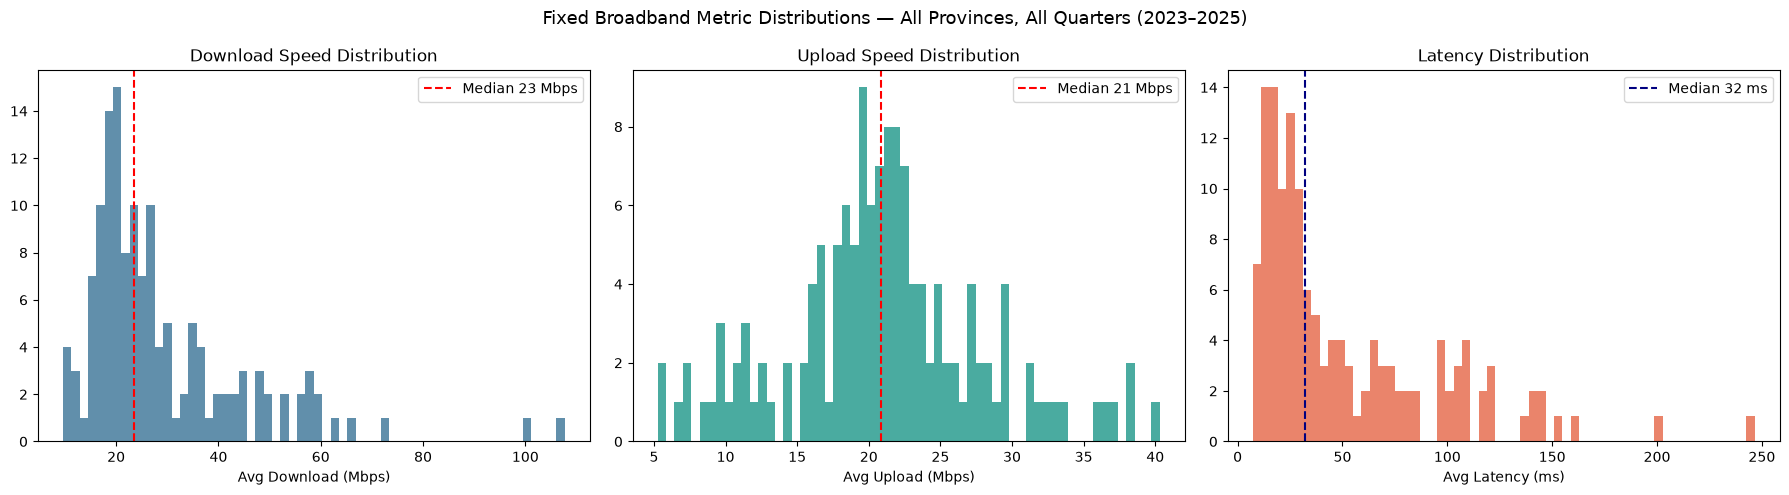

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      139.00      139.00         139.00       139.00
mean        29.08       20.93          51.37     12172.95
std         16.07        6.88          43.76     25821.61
min          9.58        5.26           7.18       101.00
25%         18.65       17.71          19.21      1768.50
50%         23.42       20.86          32.24      4704.00
75%         35.18       24.13          72.11      8442.00
max        107.72       40.32         246.57    143112.00


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

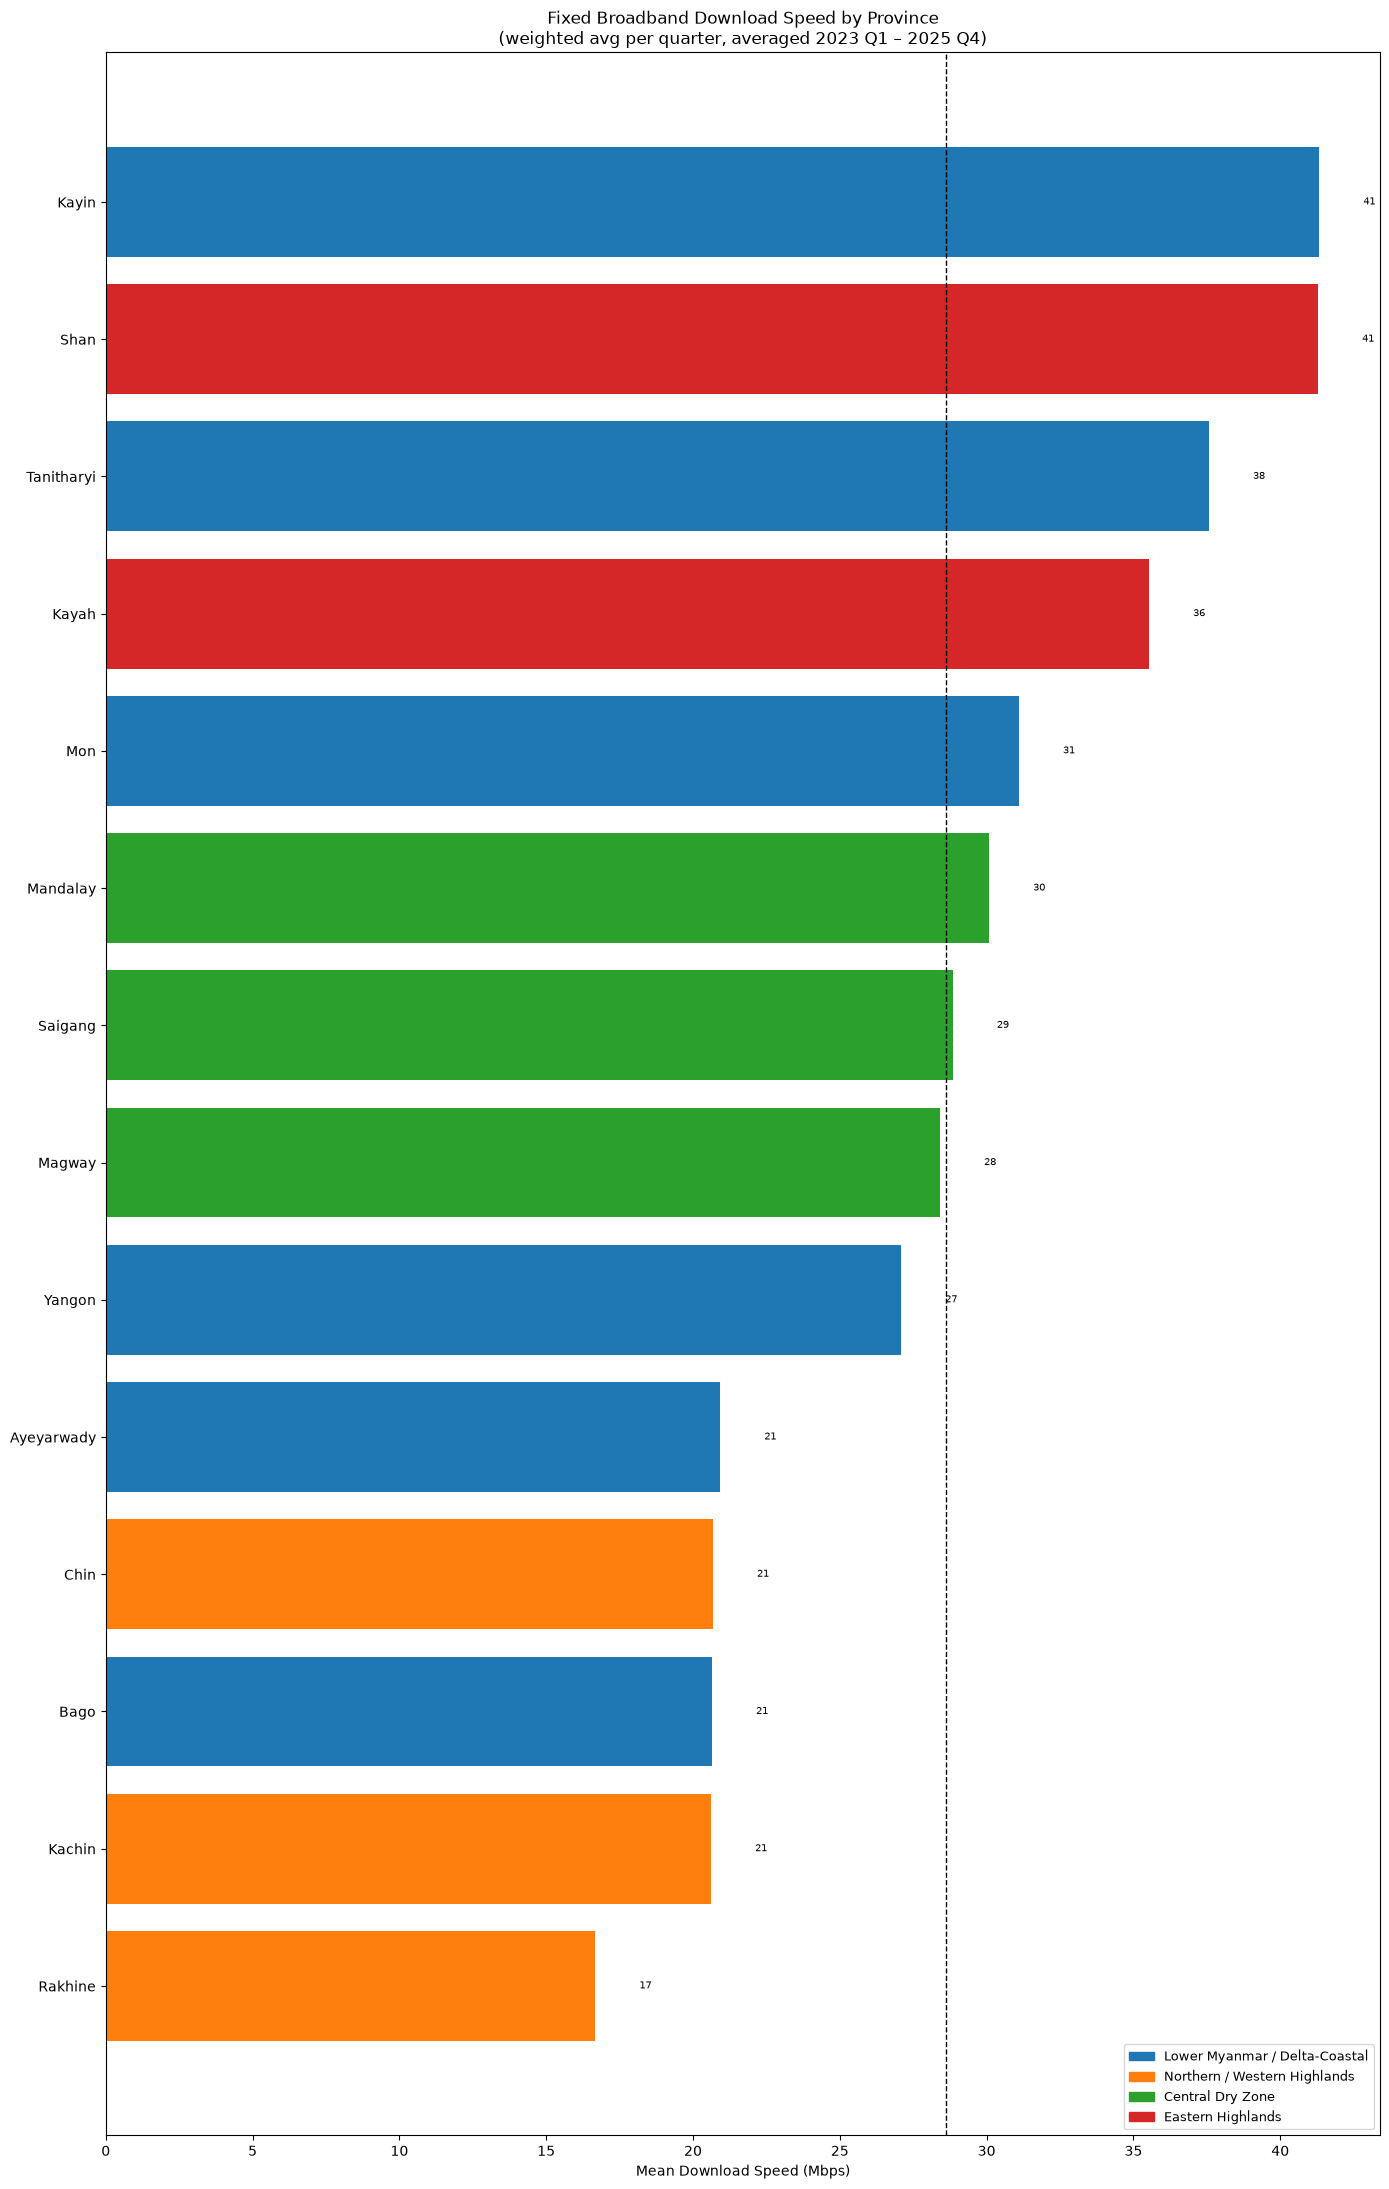

In [25]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

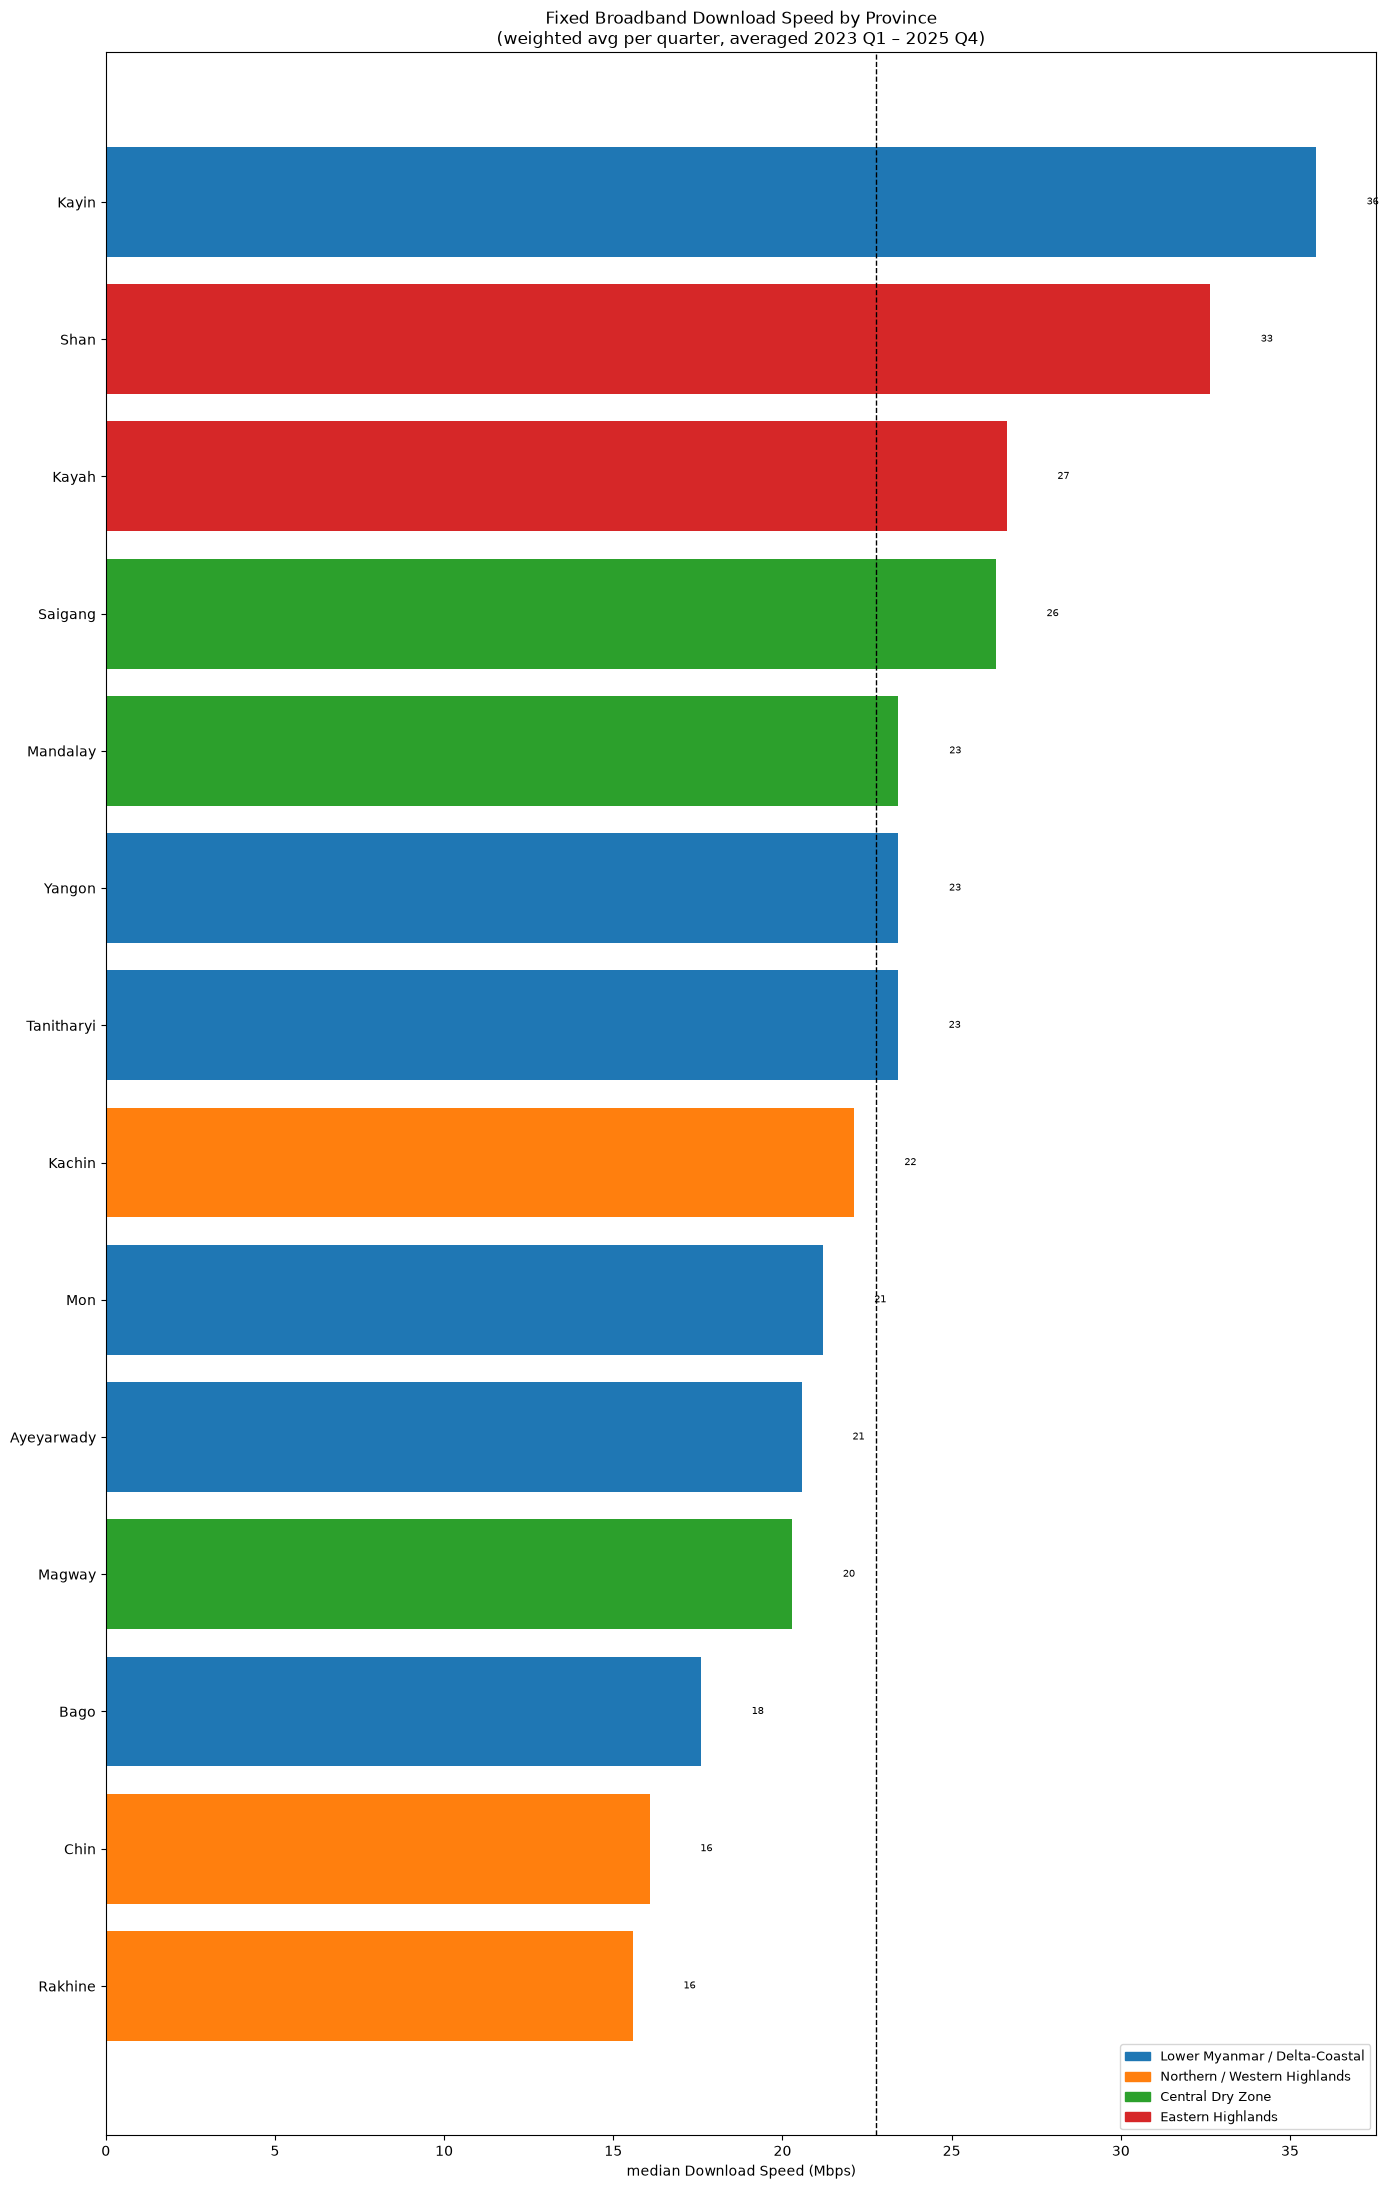

In [26]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

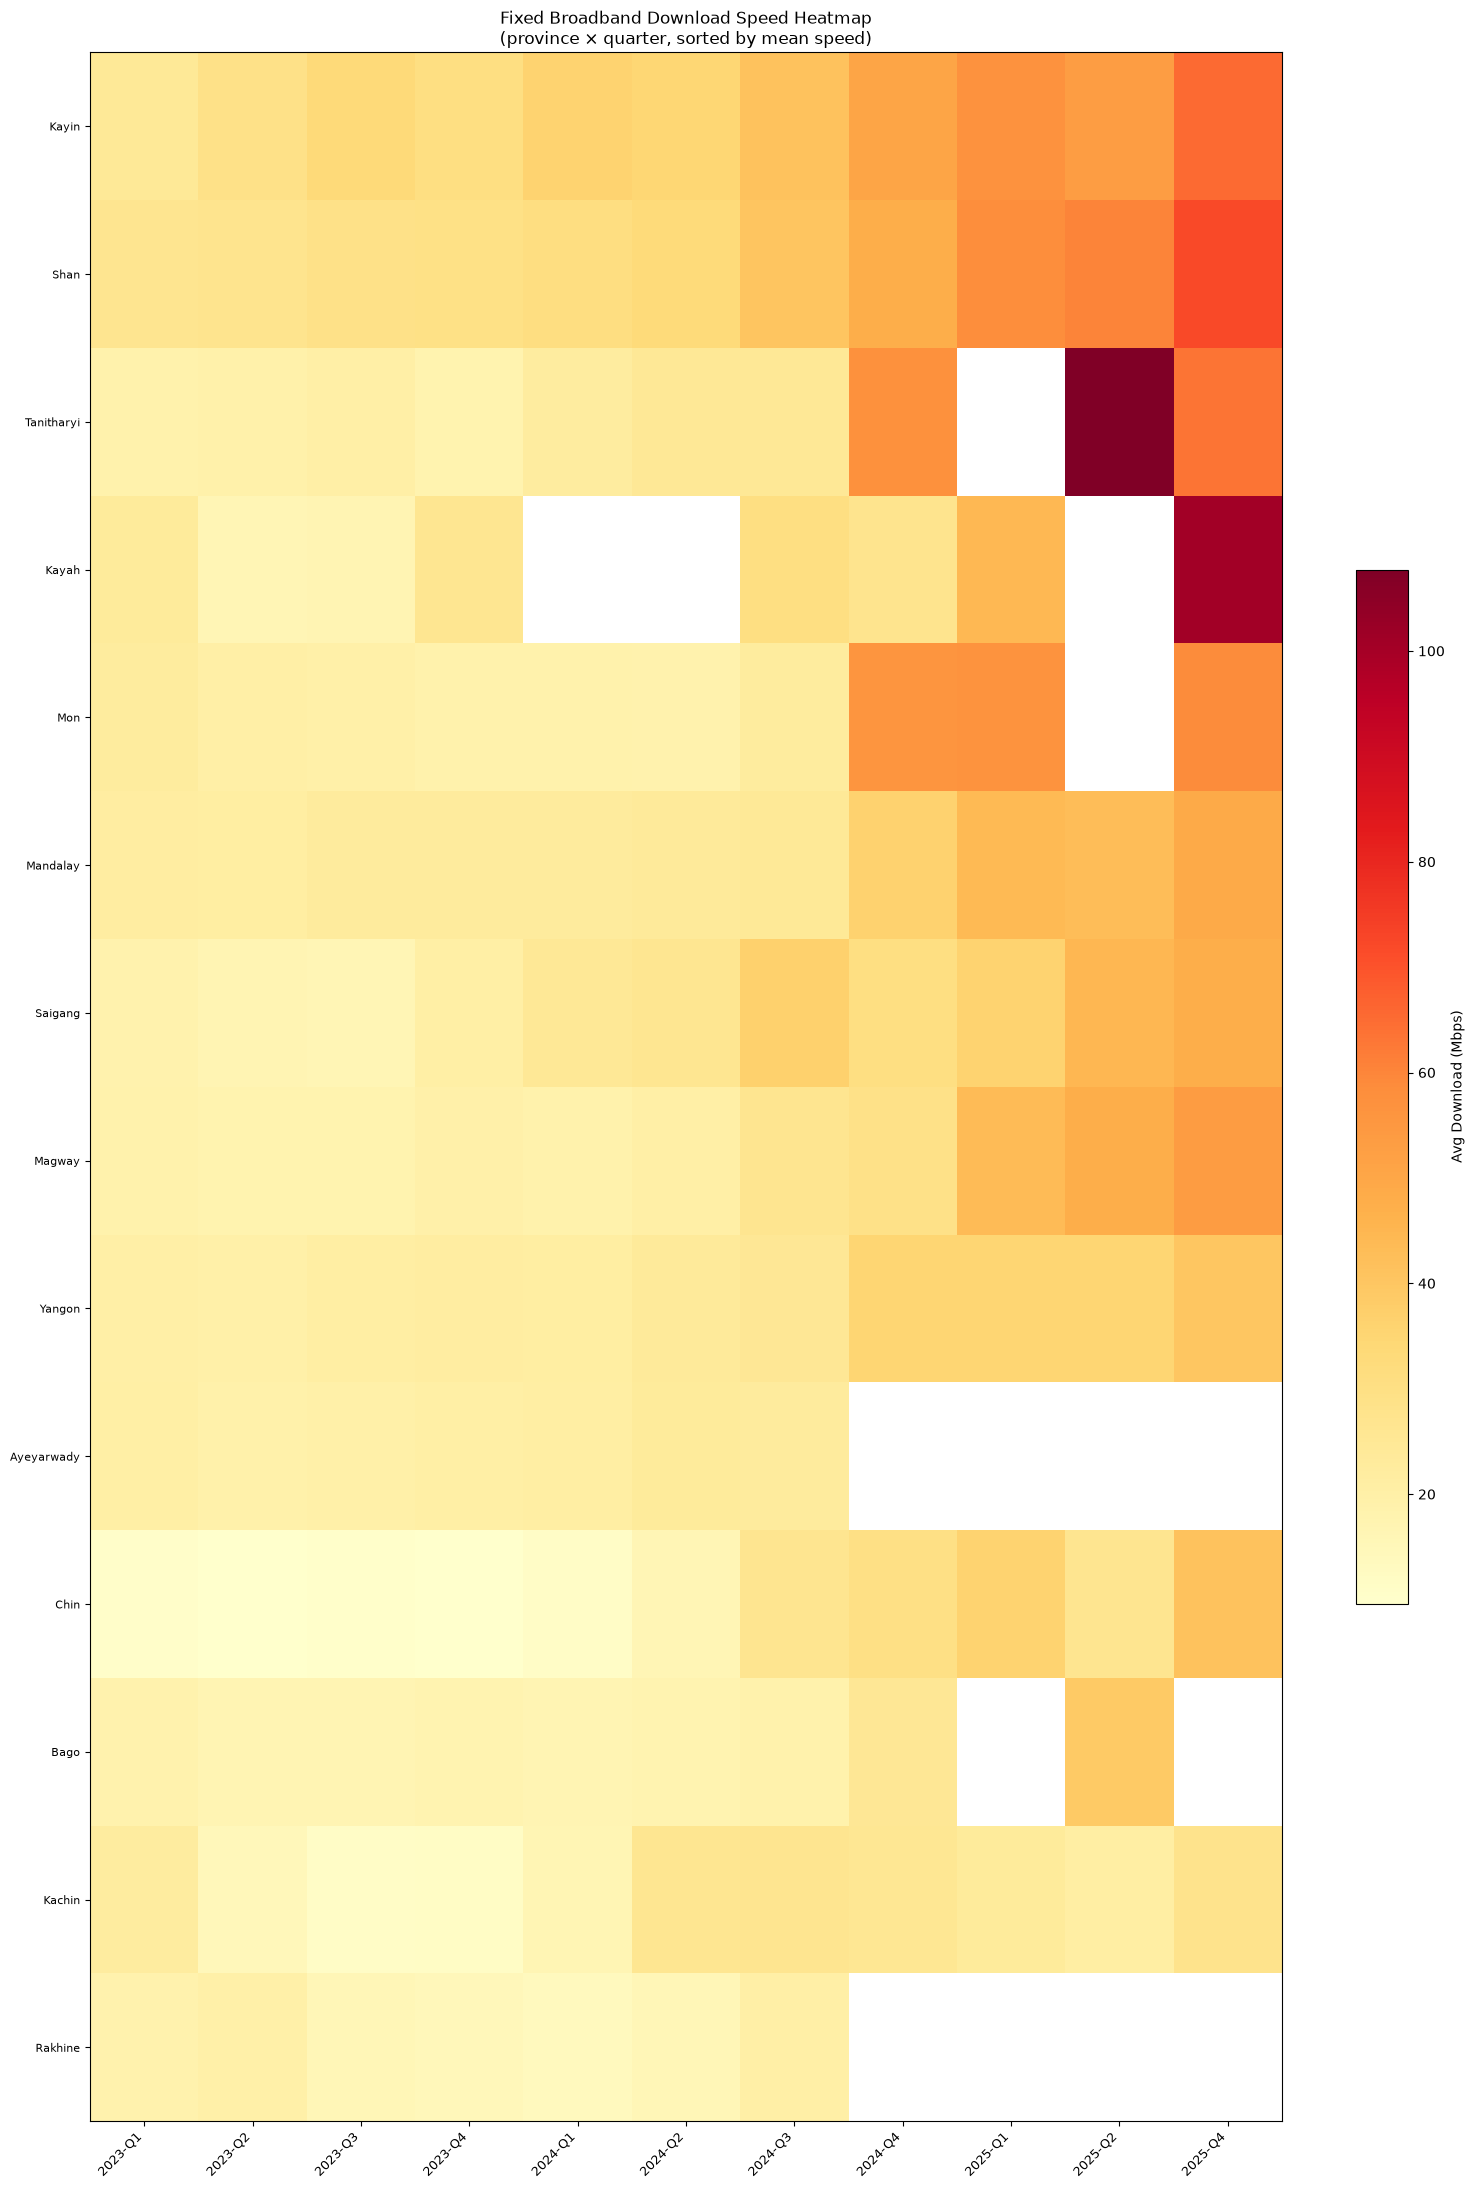

In [27]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

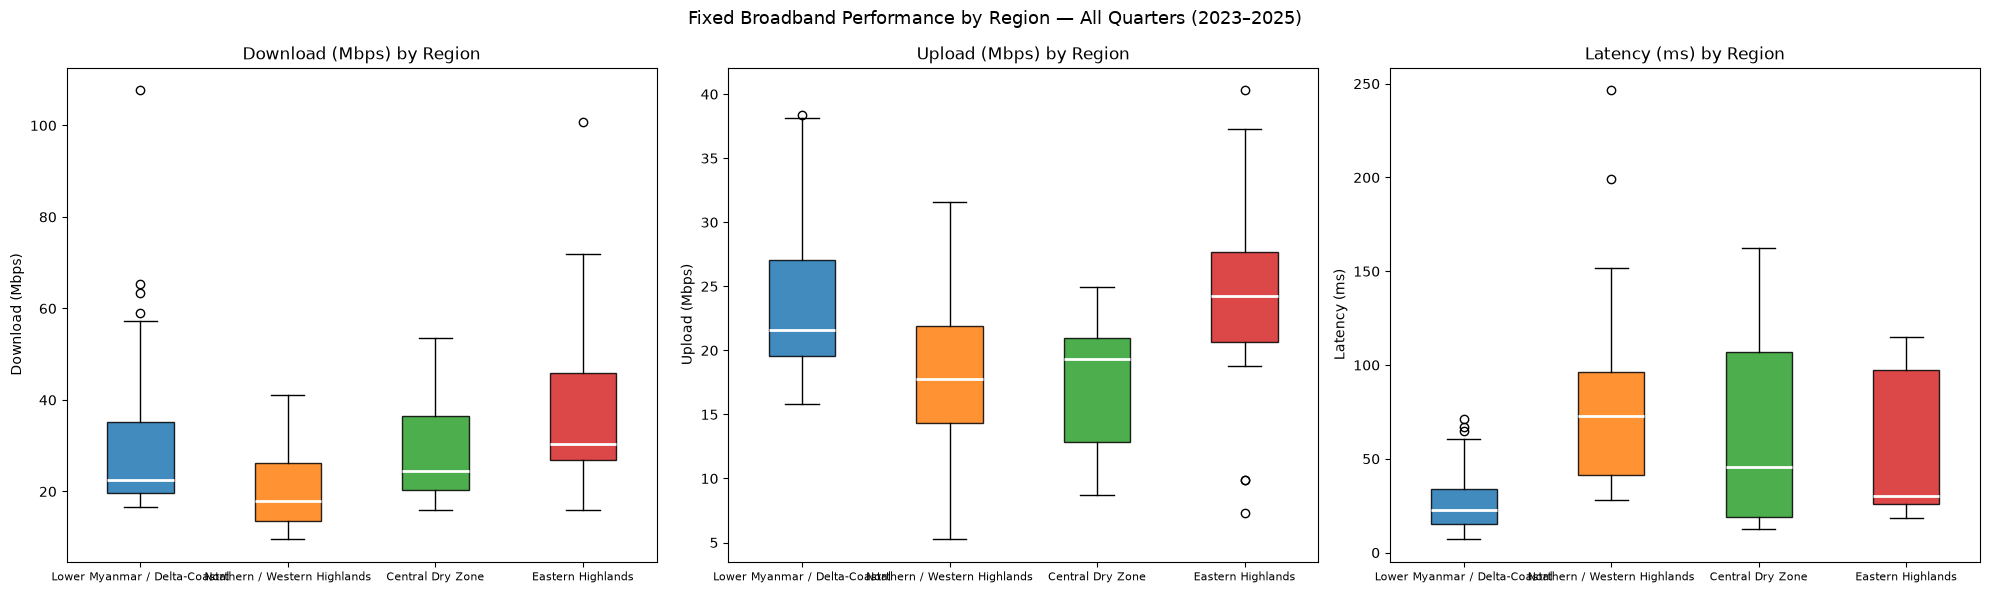

In [28]:
region_order = ['Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands', 'Central Dry Zone', 'Eastern Highlands']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

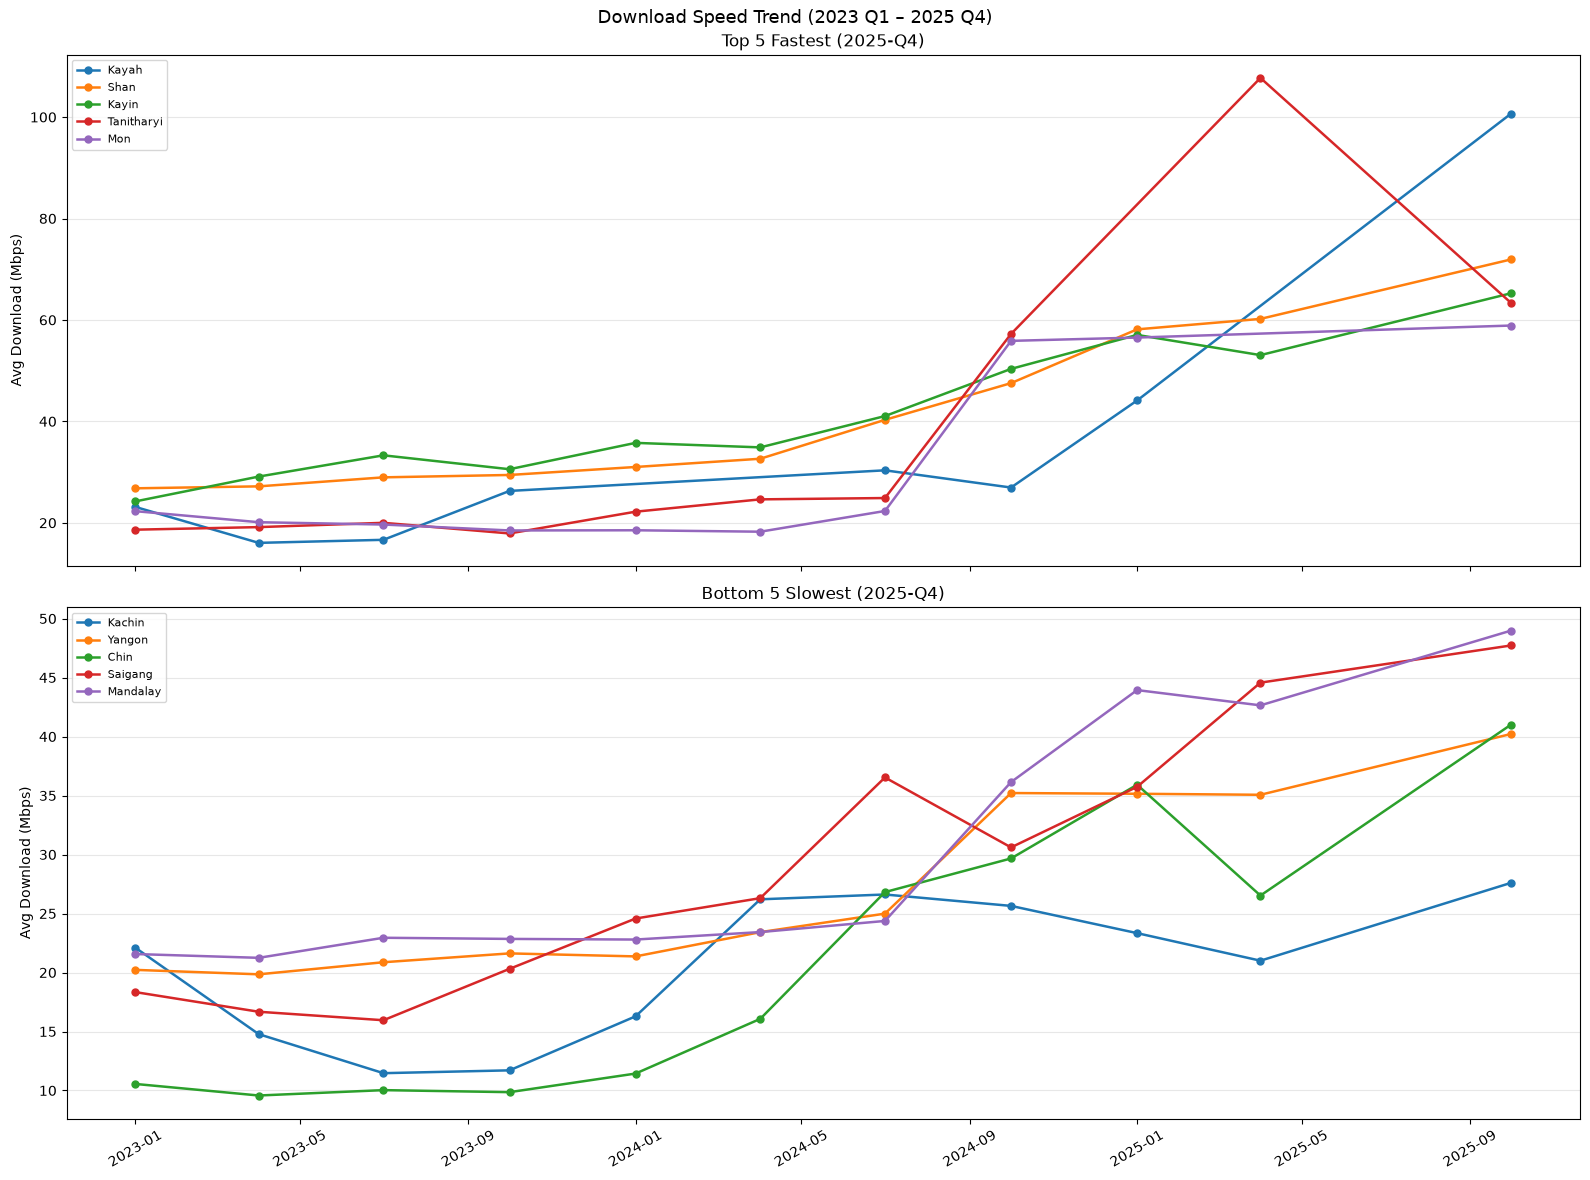

In [29]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

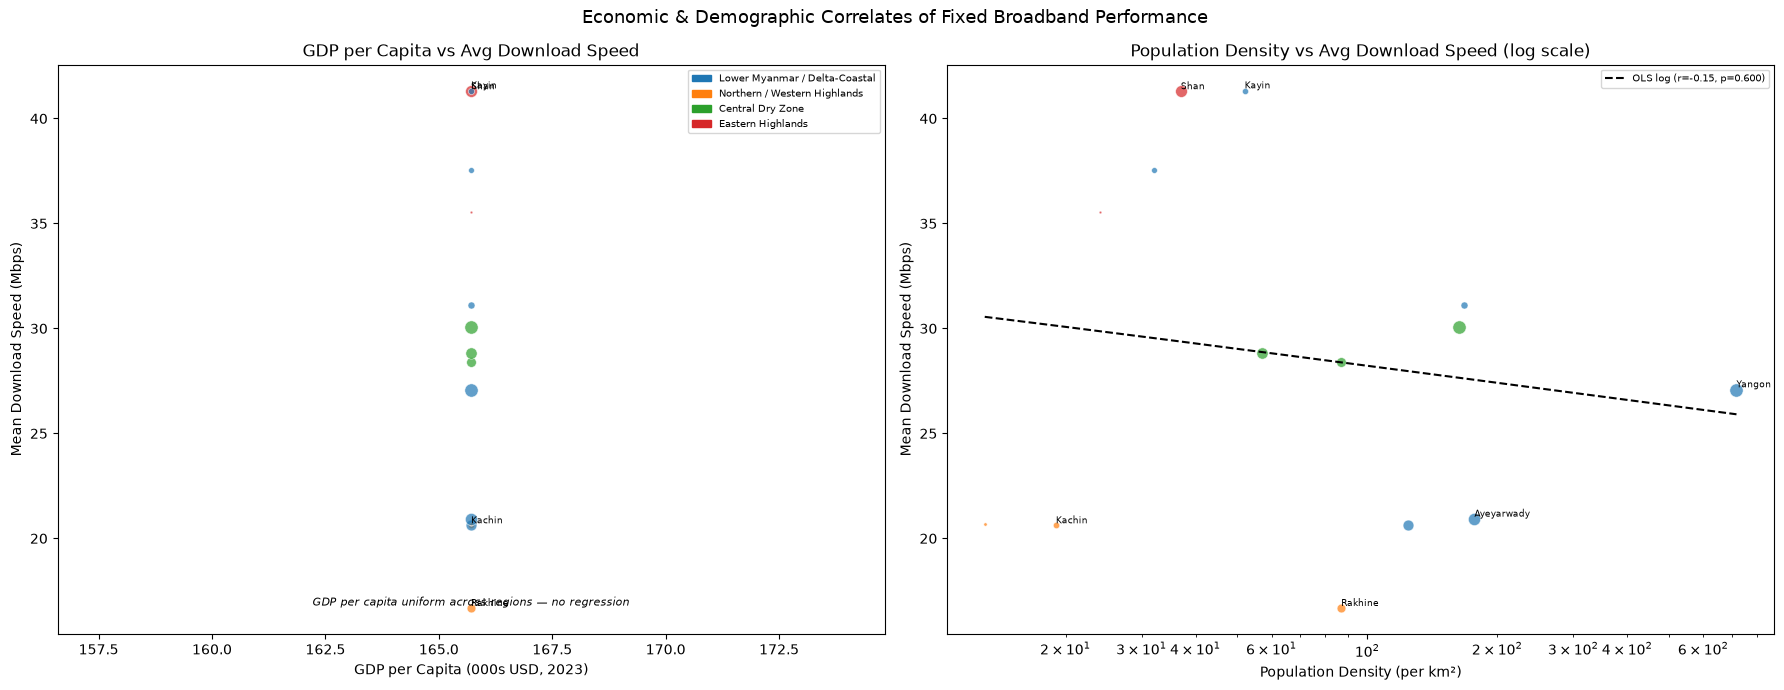

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): -0.154  p=0.5999


In [30]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [31]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     2.751
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.119
Time:                        20:00:47   Log-Likelihood:                -38.573
No. Observations:                  14   AIC:                             93.15
Df Residuals:                       6   BIC:                             98.26
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

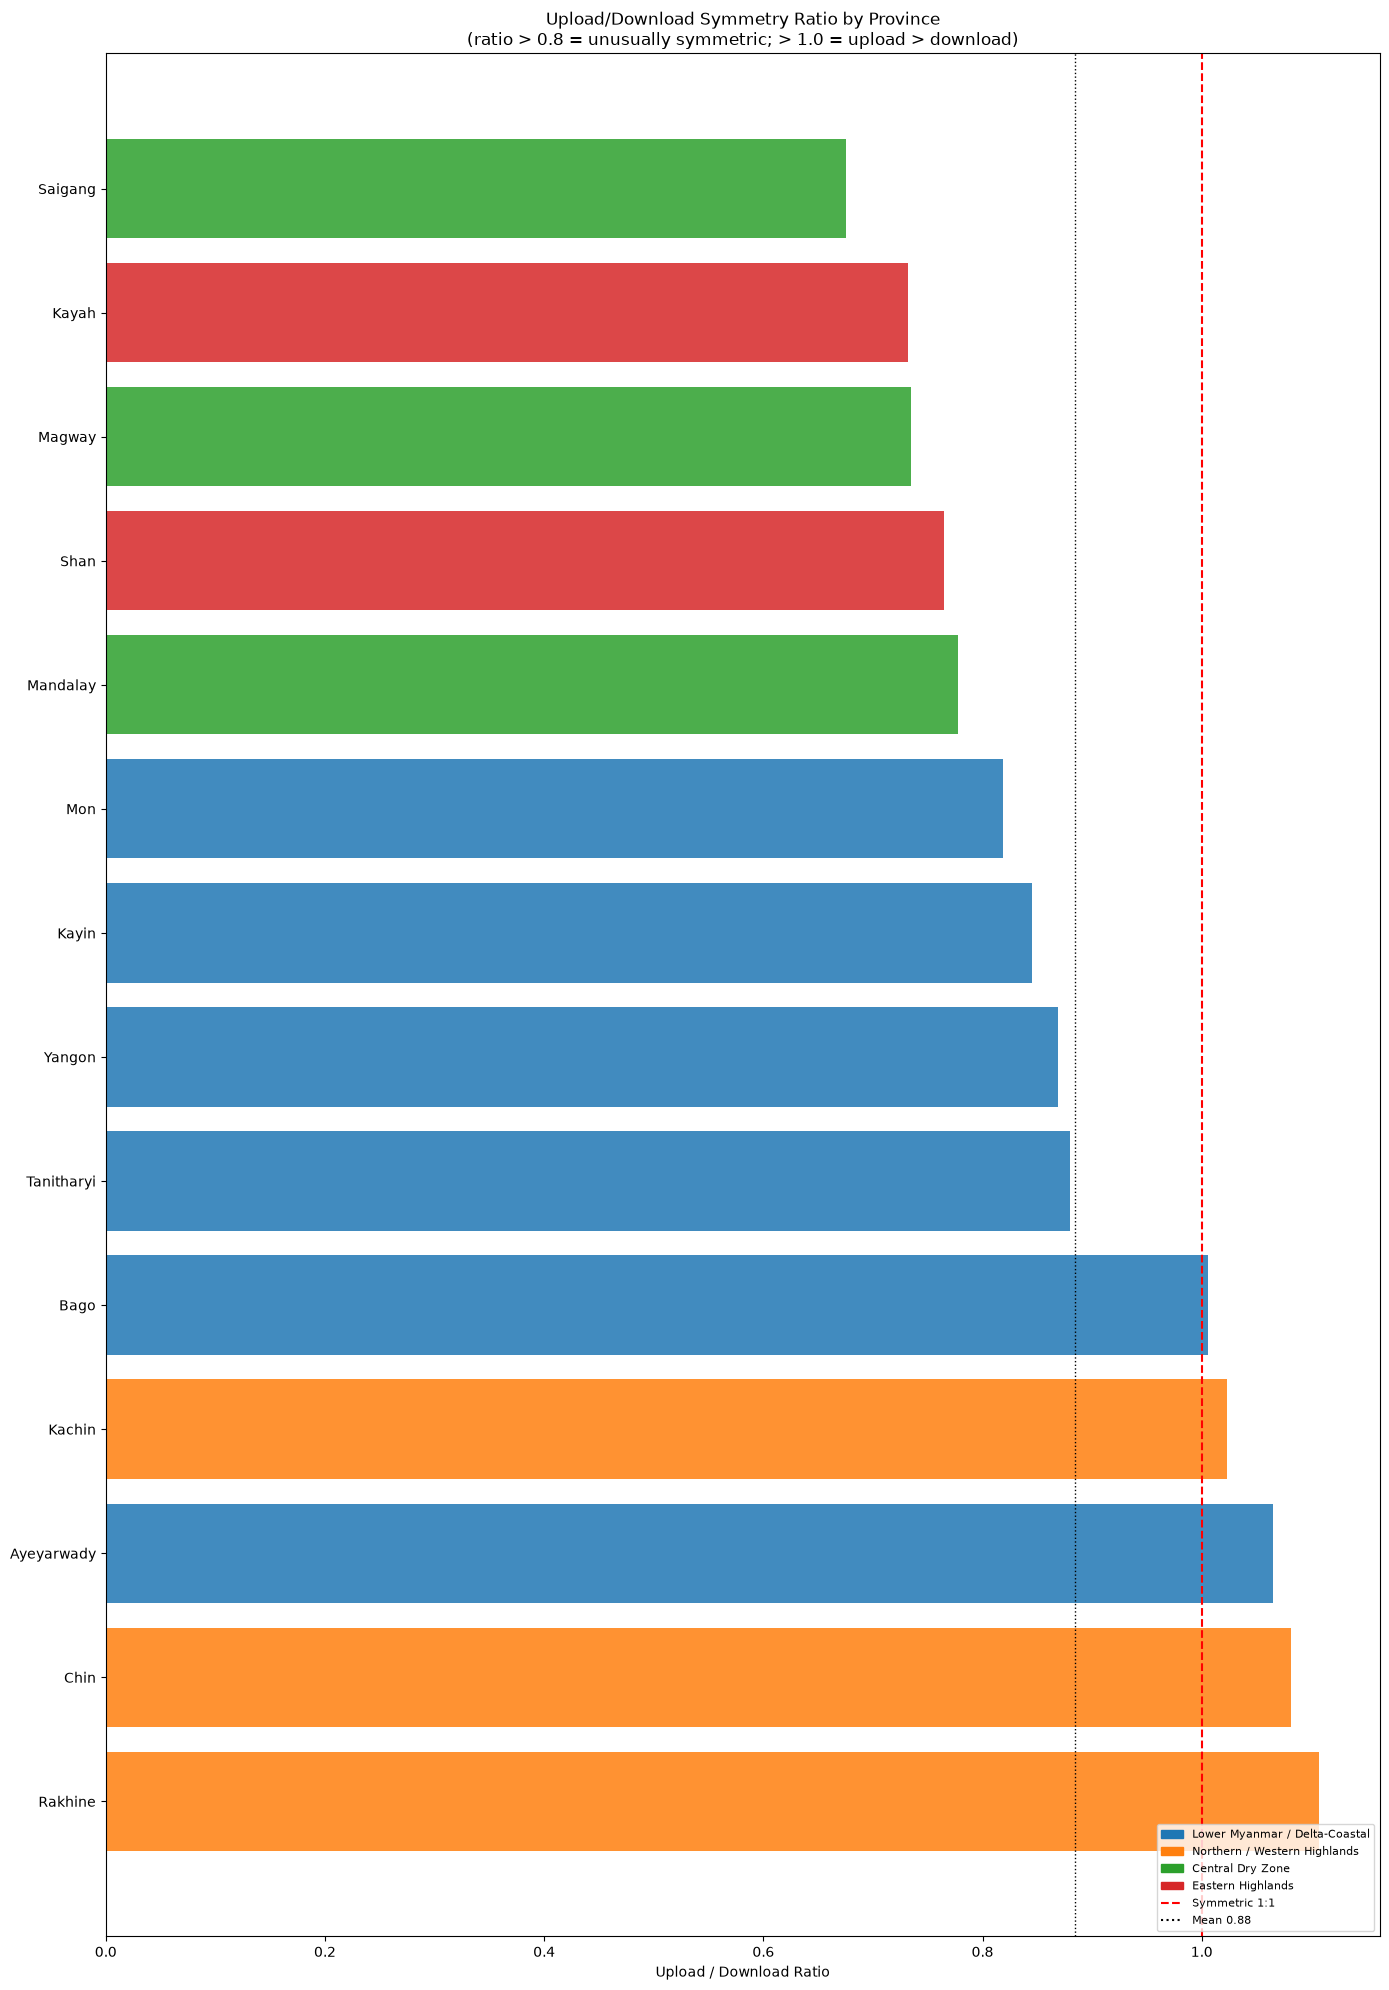

Provinces with UL/DL ratio > 0.8 (9):
      name                        region  ul_dl_ratio
   Rakhine  Northern / Western Highlands     1.107308
      Chin  Northern / Western Highlands     1.081541
Ayeyarwady Lower Myanmar / Delta-Coastal     1.065122
    Kachin  Northern / Western Highlands     1.023093
      Bago Lower Myanmar / Delta-Coastal     1.005326
Tanitharyi Lower Myanmar / Delta-Coastal     0.879926
    Yangon Lower Myanmar / Delta-Coastal     0.868560
     Kayin Lower Myanmar / Delta-Coastal     0.844809
       Mon Lower Myanmar / Delta-Coastal     0.818641


In [32]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [33]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [34]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

      name                        region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
     Kayin Lower Myanmar / Delta-Coastal              3    41.33    32.83     36.95         0.84     4525.55                 165710.4
      Shan             Eastern Highlands              3    41.29    27.81     47.61         0.76    14934.27                 165710.4
Tanitharyi Lower Myanmar / Delta-Coastal              4    37.57    23.30     36.89         0.88     1980.60                 165710.4
     Kayah             Eastern Highlands              4    35.53    17.77     63.17         0.73      270.25                 165710.4
       Mon Lower Myanmar / Delta-Coastal              1    31.10    19.63     31.59         0.82     4333.00                 165710.4
  Mandalay              Central Dry Zone              1    30.08    20.13     44.58         0.78    18658.18                 165710.4
   Saigang              Central Dry Zone              3    28.

### 13. UL/DL Symmetry — Fiber Penetration Evidence

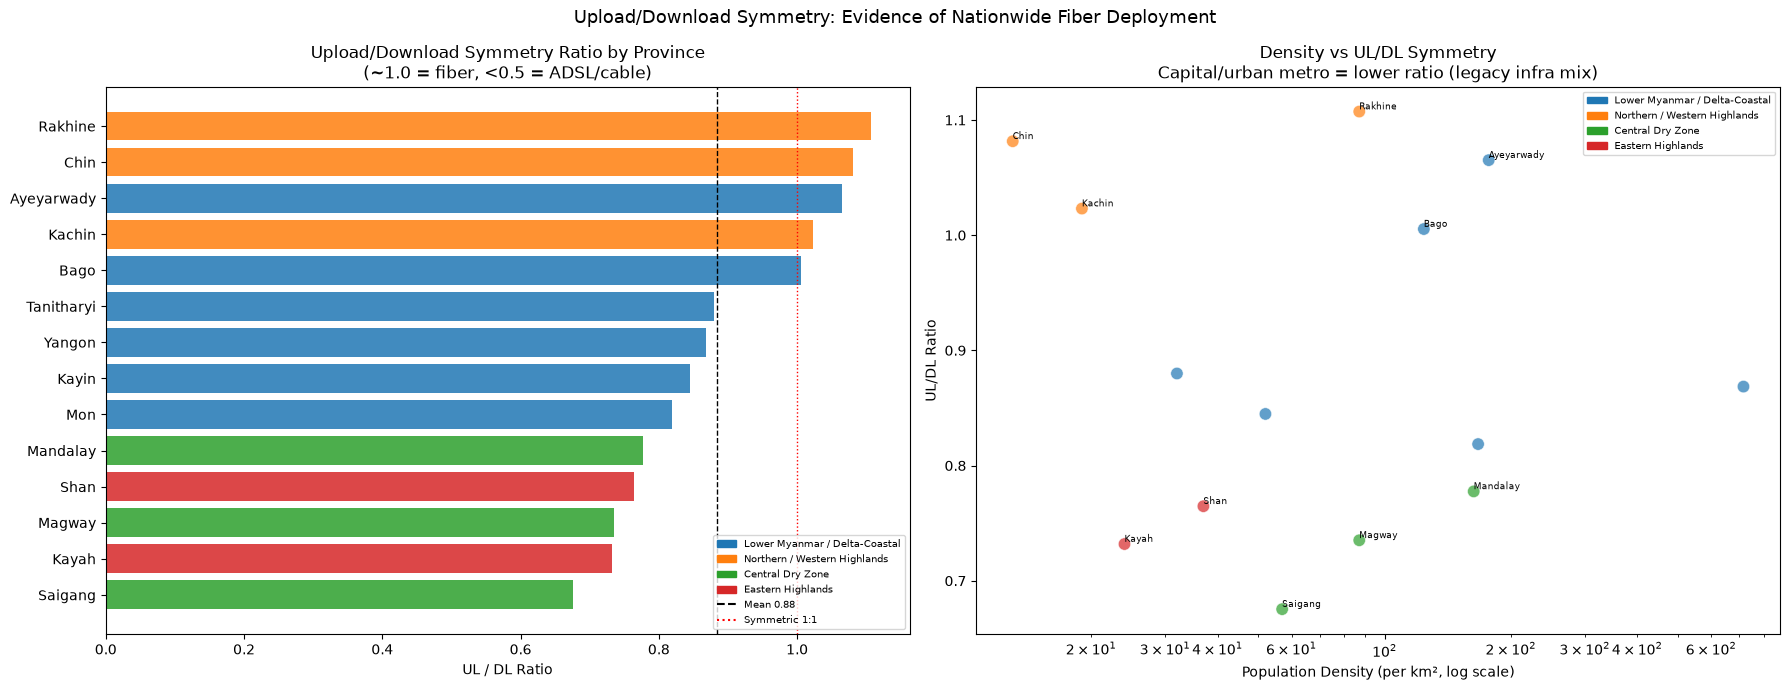

Provinces ratio > 0.90: 5 (near-perfect fiber)
Provinces ratio > 0.80: 9 out of 14
Lower Myanmar / Delta-Coastal min ratio: 0.819
Lower Myanmar / Delta-Coastal max ratio: 1.065


In [35]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nCapital/urban metro = lower ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

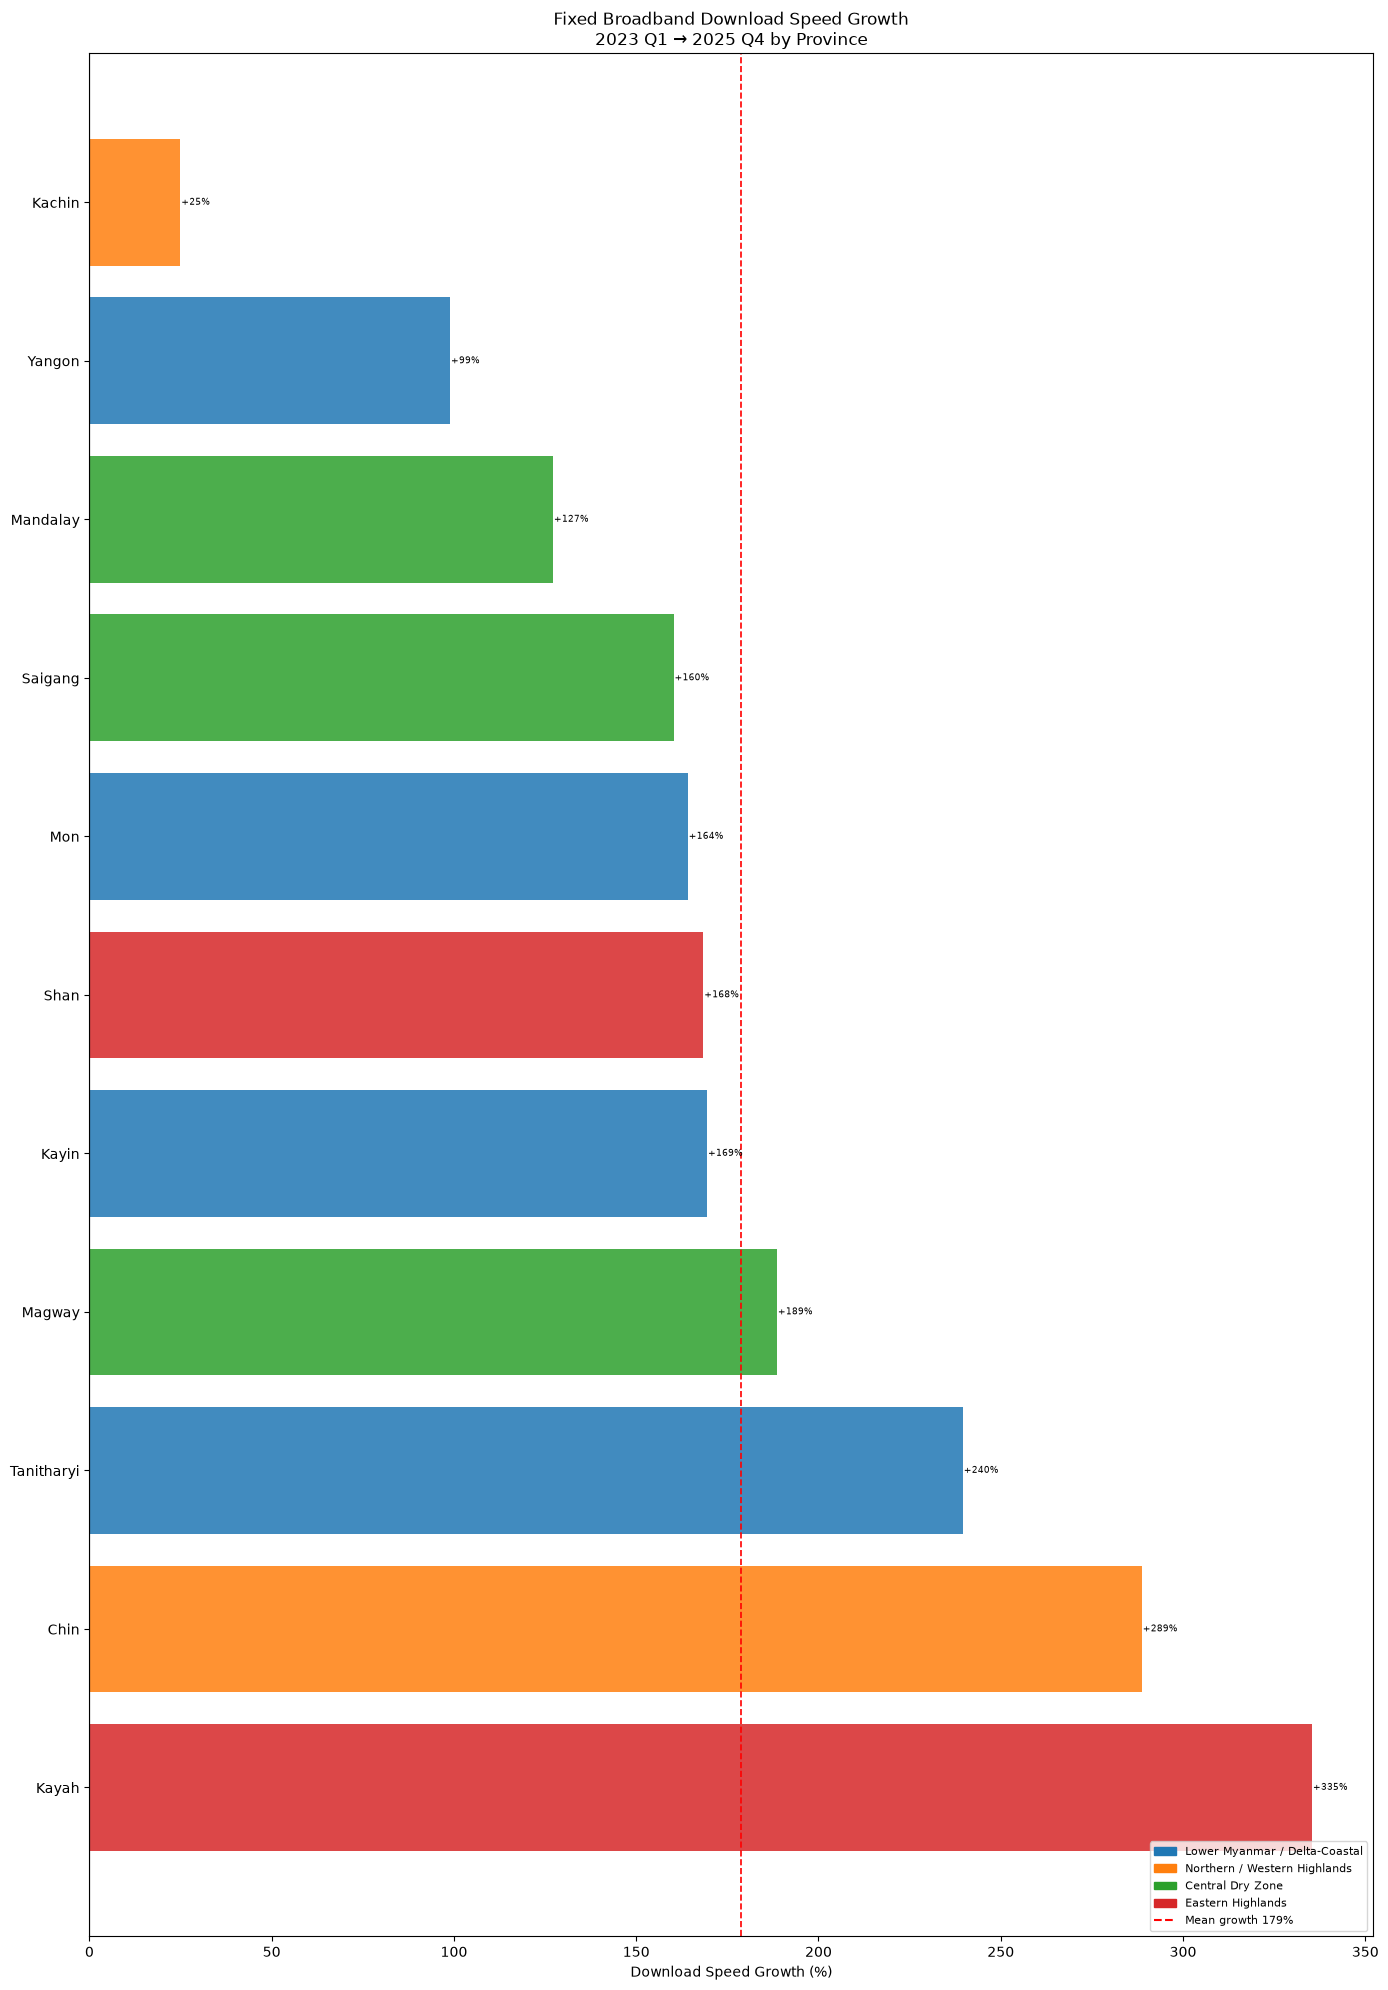

Top 10 fastest growing provinces:
      name                        region  internet_tier  pct_growth
     Kayah             Eastern Highlands              4  335.351154
      Chin  Northern / Western Highlands              4  288.670377
Tanitharyi Lower Myanmar / Delta-Coastal              4  239.572428
    Magway              Central Dry Zone              2  188.577495
     Kayin Lower Myanmar / Delta-Coastal              3  169.414556
      Shan             Eastern Highlands              3  168.376301
       Mon Lower Myanmar / Delta-Coastal              1  164.114684
   Saigang              Central Dry Zone              3  160.231711
  Mandalay              Central Dry Zone              1  127.137325
    Yangon Lower Myanmar / Delta-Coastal              1   98.897331

Bottom 5 (slowest growth or decline):
    name                        region  internet_tier  pct_growth
  Kachin  Northern / Western Highlands              4   24.908825
  Yangon Lower Myanmar / Delta-Coastal         

In [36]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [37]:
# ── Export Ookla quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_myanmar_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 139 rows → ../../data/exports/ookla_myanmar_province_quarterly.csv
     province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable                         region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Ayeyarwady  2023-Q1  2023        1   20.390589   22.579090      28.663590       5309.0    556.0         True  Lower Myanmar / Delta-Coastal              1   6184829                 165710.4              177
1        Bago  2023-Q1  2023        1   18.147305   20.514208      14.996597       7934.0    820.0         True  Lower Myanmar / Delta-Coastal              2   4867373                 165710.4              124
2        Chin  2023-Q1  2023        1   10.554737   15.778141      72.978593        327.0     34.0         True   Northern / Western Highlands              4    478801                 165710.4               13


---
# Part 2 — Mobile/Cellular


## Full EDA — Ookla Mobile/Cellular, Myanmar (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [38]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/myanmar_provinces.geojson'
PROV_REF    = '../../data/reference/myanmar_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_mobile_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*mobile_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   71,146 raw tiles → 14 provinces


  2023-Q2 (2023-04-01):   67,058 raw tiles → 14 provinces


  2023-Q3 (2023-07-01):   66,592 raw tiles → 14 provinces


  2023-Q4 (2023-10-01):   68,838 raw tiles → 14 provinces


  2024-Q1 (2024-01-01):   66,090 raw tiles → 13 provinces


...

  2024-Q4 (2024-10-01):   57,450 raw tiles → 14 provinces


  2025-Q1 (2025-01-01):   52,813 raw tiles → 14 provinces


  2025-Q2 (2025-04-01):   53,729 raw tiles → 12 provinces


  2025-Q3 (2025-07-01):   49,778 raw tiles → 13 provinces


  2025-Q4 (2025-10-01):   53,341 raw tiles → 13 provinces

Master shape: (162, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  14

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-07-01
  2025-10-01


In [39]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    14
2023-Q2    14
2023-Q3    14
2023-Q4    13
2024-Q1    13
2024-Q2    13
2024-Q3    11
2024-Q4    10
2025-Q1     7
2025-Q2     7
2025-Q3     8
2025-Q4     7

Overall reliable: 131 / 162 (80.9%)


### 2. Data Quality — Coverage per Province

In [40]:
# Expected: 14 provinces × 12 quarters = 168 rows
expected = len(prov_ref) * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 168 | Actual: 162 | Missing: 6

Missing province-quarter combos (6):
  Kayah — 2024-Q1
  Kayah — 2025-Q3
  Kayah — 2025-Q4
  Kayah — 2024-Q2
  Rakhine — 2025-Q2
  Chin — 2025-Q2

Low-test quarters (< 100 tests) — 31 cases:
      name   label  total_tests  n_tiles
     Kayah 2024-Q3          1.0      1.0
     Kayah 2024-Q4          1.0      1.0
    Kachin 2025-Q1          1.0      1.0
   Rakhine 2024-Q4          2.0      1.0
   Rakhine 2025-Q1          2.0      2.0
     Kayah 2025-Q2          2.0      2.0
     Kayah 2025-Q1          5.0      2.0
      Chin 2025-Q3          6.0      4.0
   Rakhine 2025-Q3          7.0      2.0
      Chin 2024-Q4          9.0      4.0
   Rakhine 2025-Q4         10.0      5.0
    Kachin 2024-Q4         14.0      4.0
Tanitharyi 2025-Q4         21.0     16.0
      Chin 2025-Q4         21.0      3.0
Tanitharyi 2025-Q3         23.0     16.0
      Chin 2025-Q1         24.0      5.0
    Kachin 2025-Q4         24.0     10.0
    Magway 2025-Q2      

In [41]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 131 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

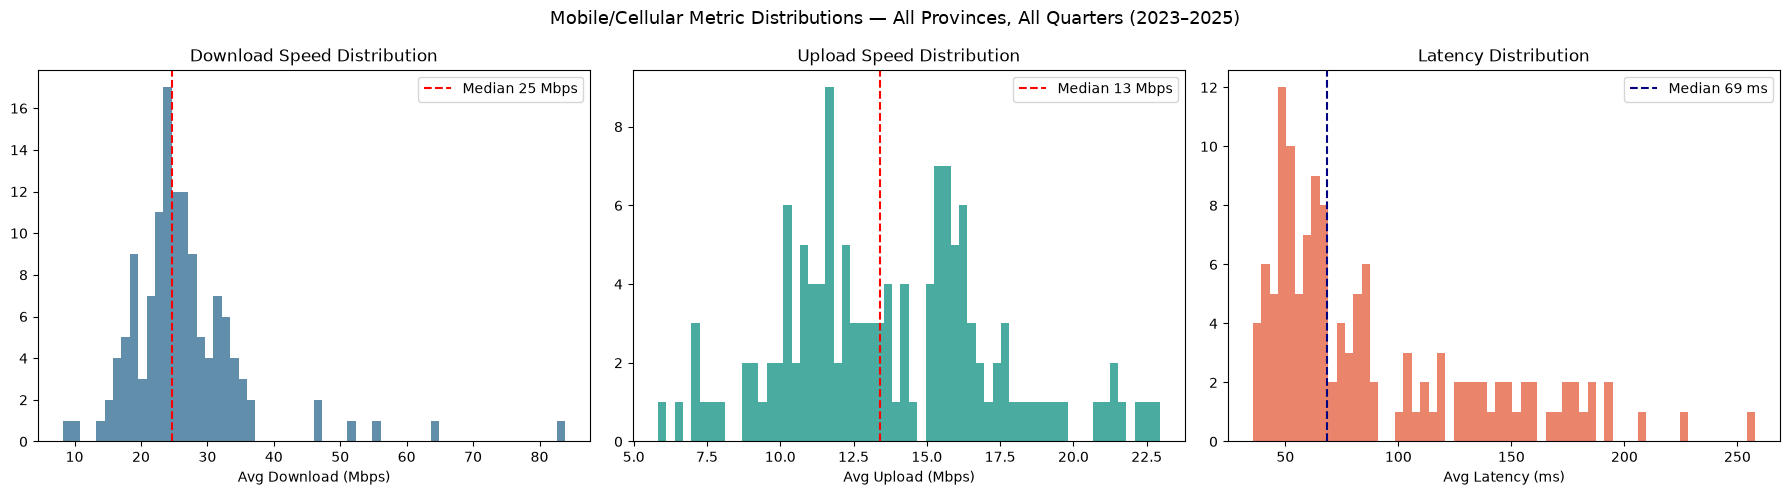

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      131.00      131.00         131.00       131.00
mean        26.51       13.75          89.86      1882.27
std          9.25        3.63          48.28      2616.19
min          8.24        5.82          35.62       104.00
25%         22.21       11.11          52.08       315.50
50%         24.72       13.39          68.62       989.00
75%         29.37       16.02         119.40      2191.00
max         83.82       22.95         257.73     15360.00


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

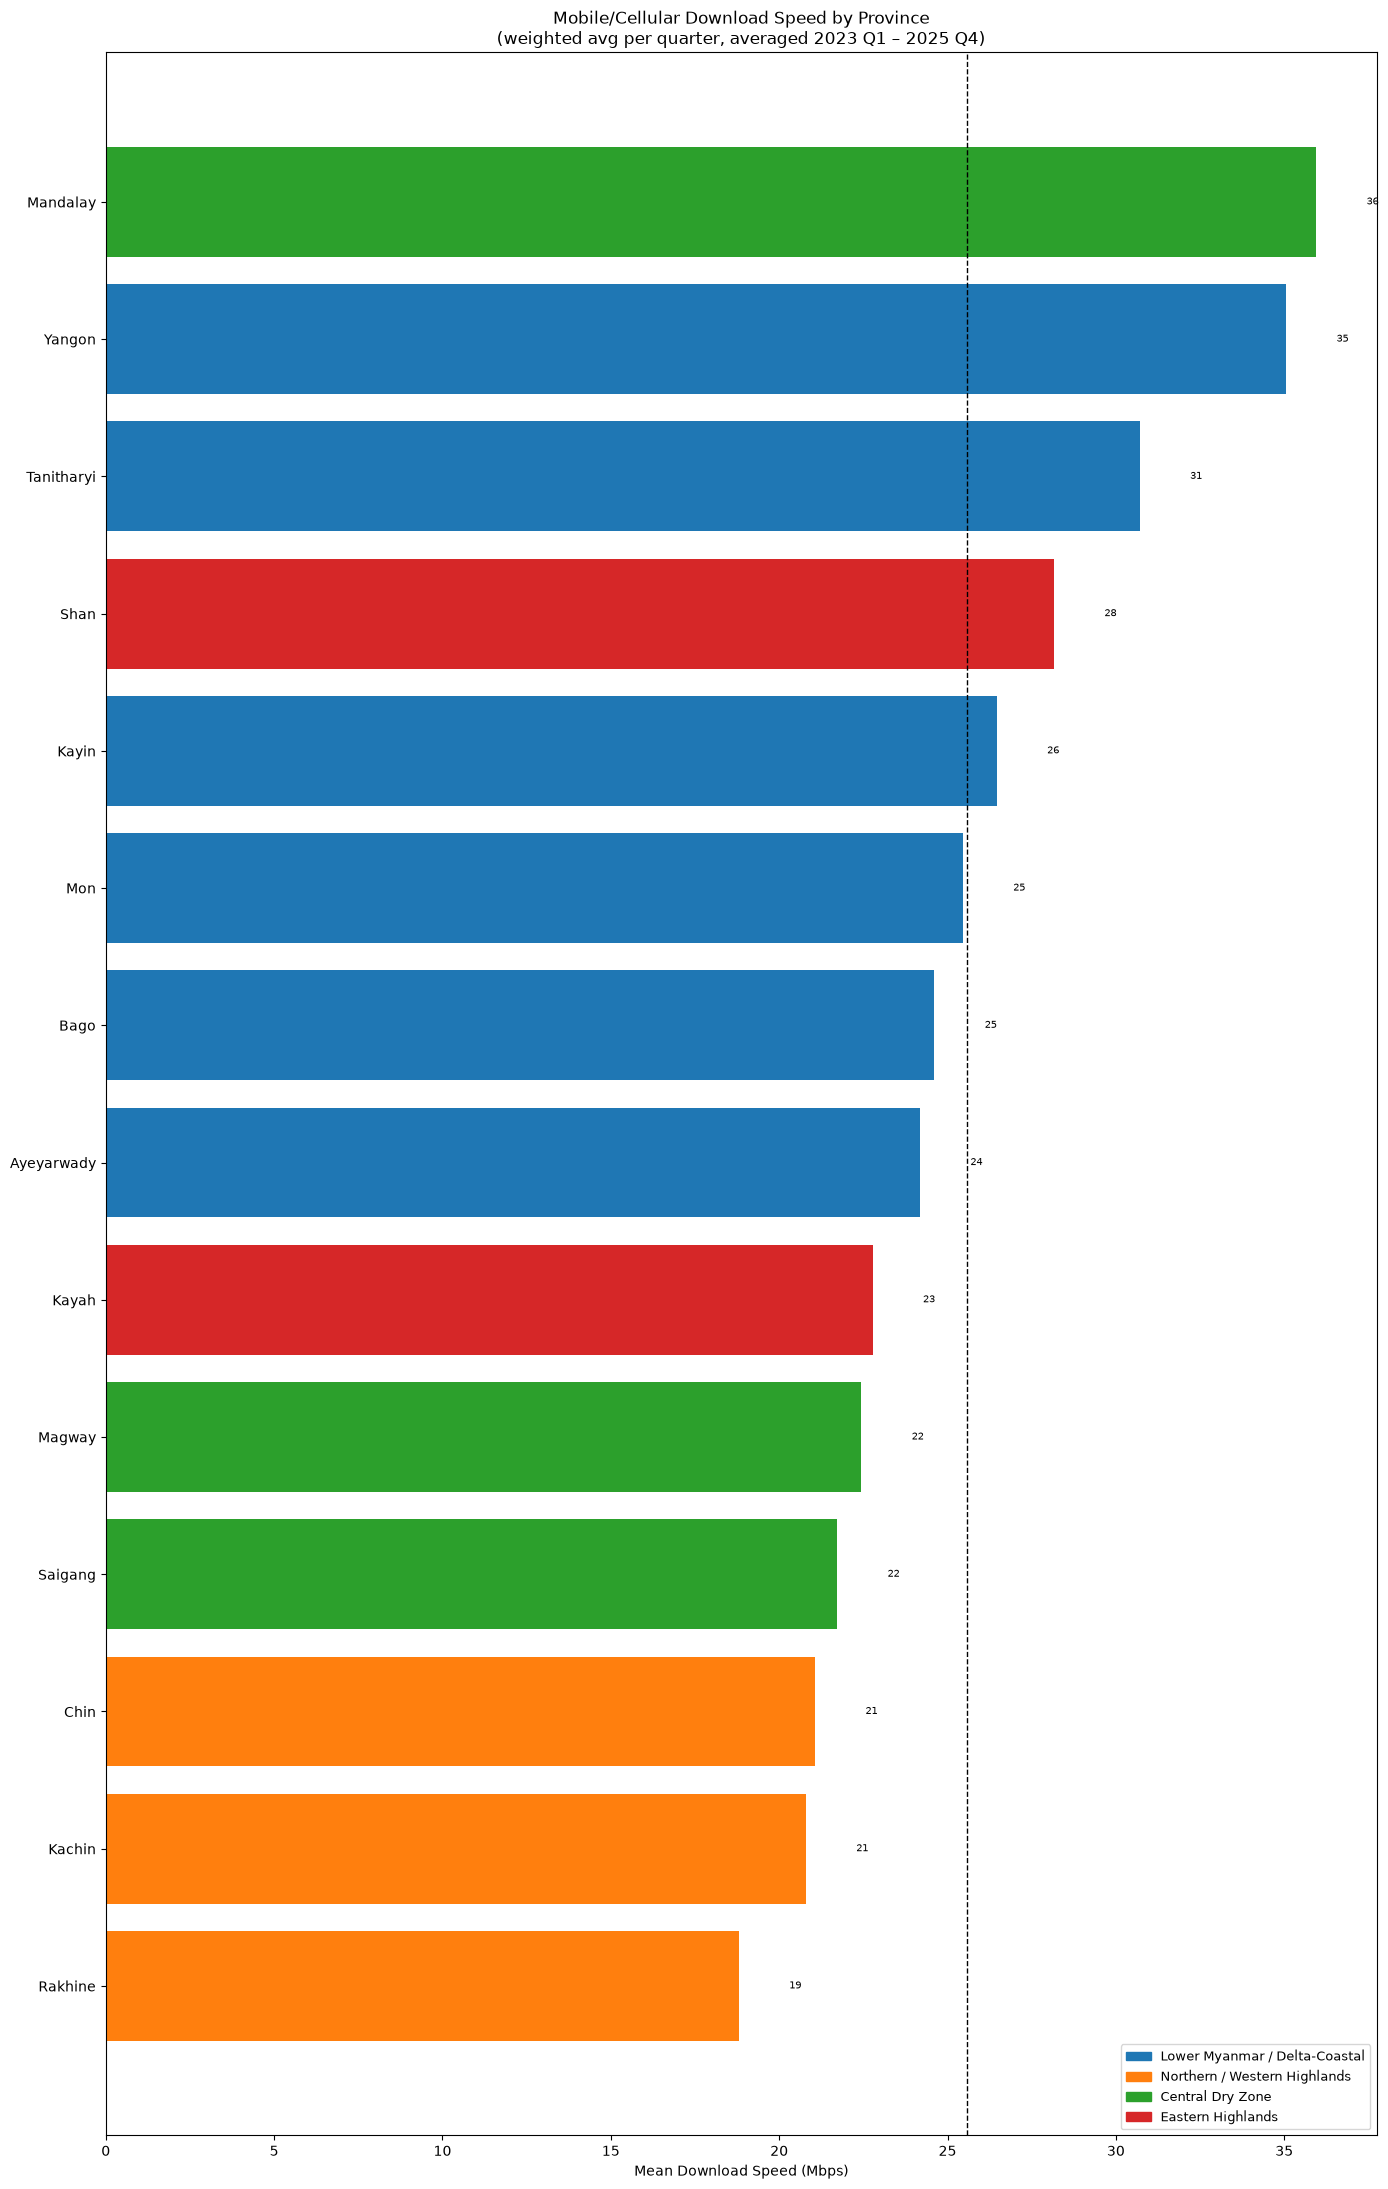

In [43]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

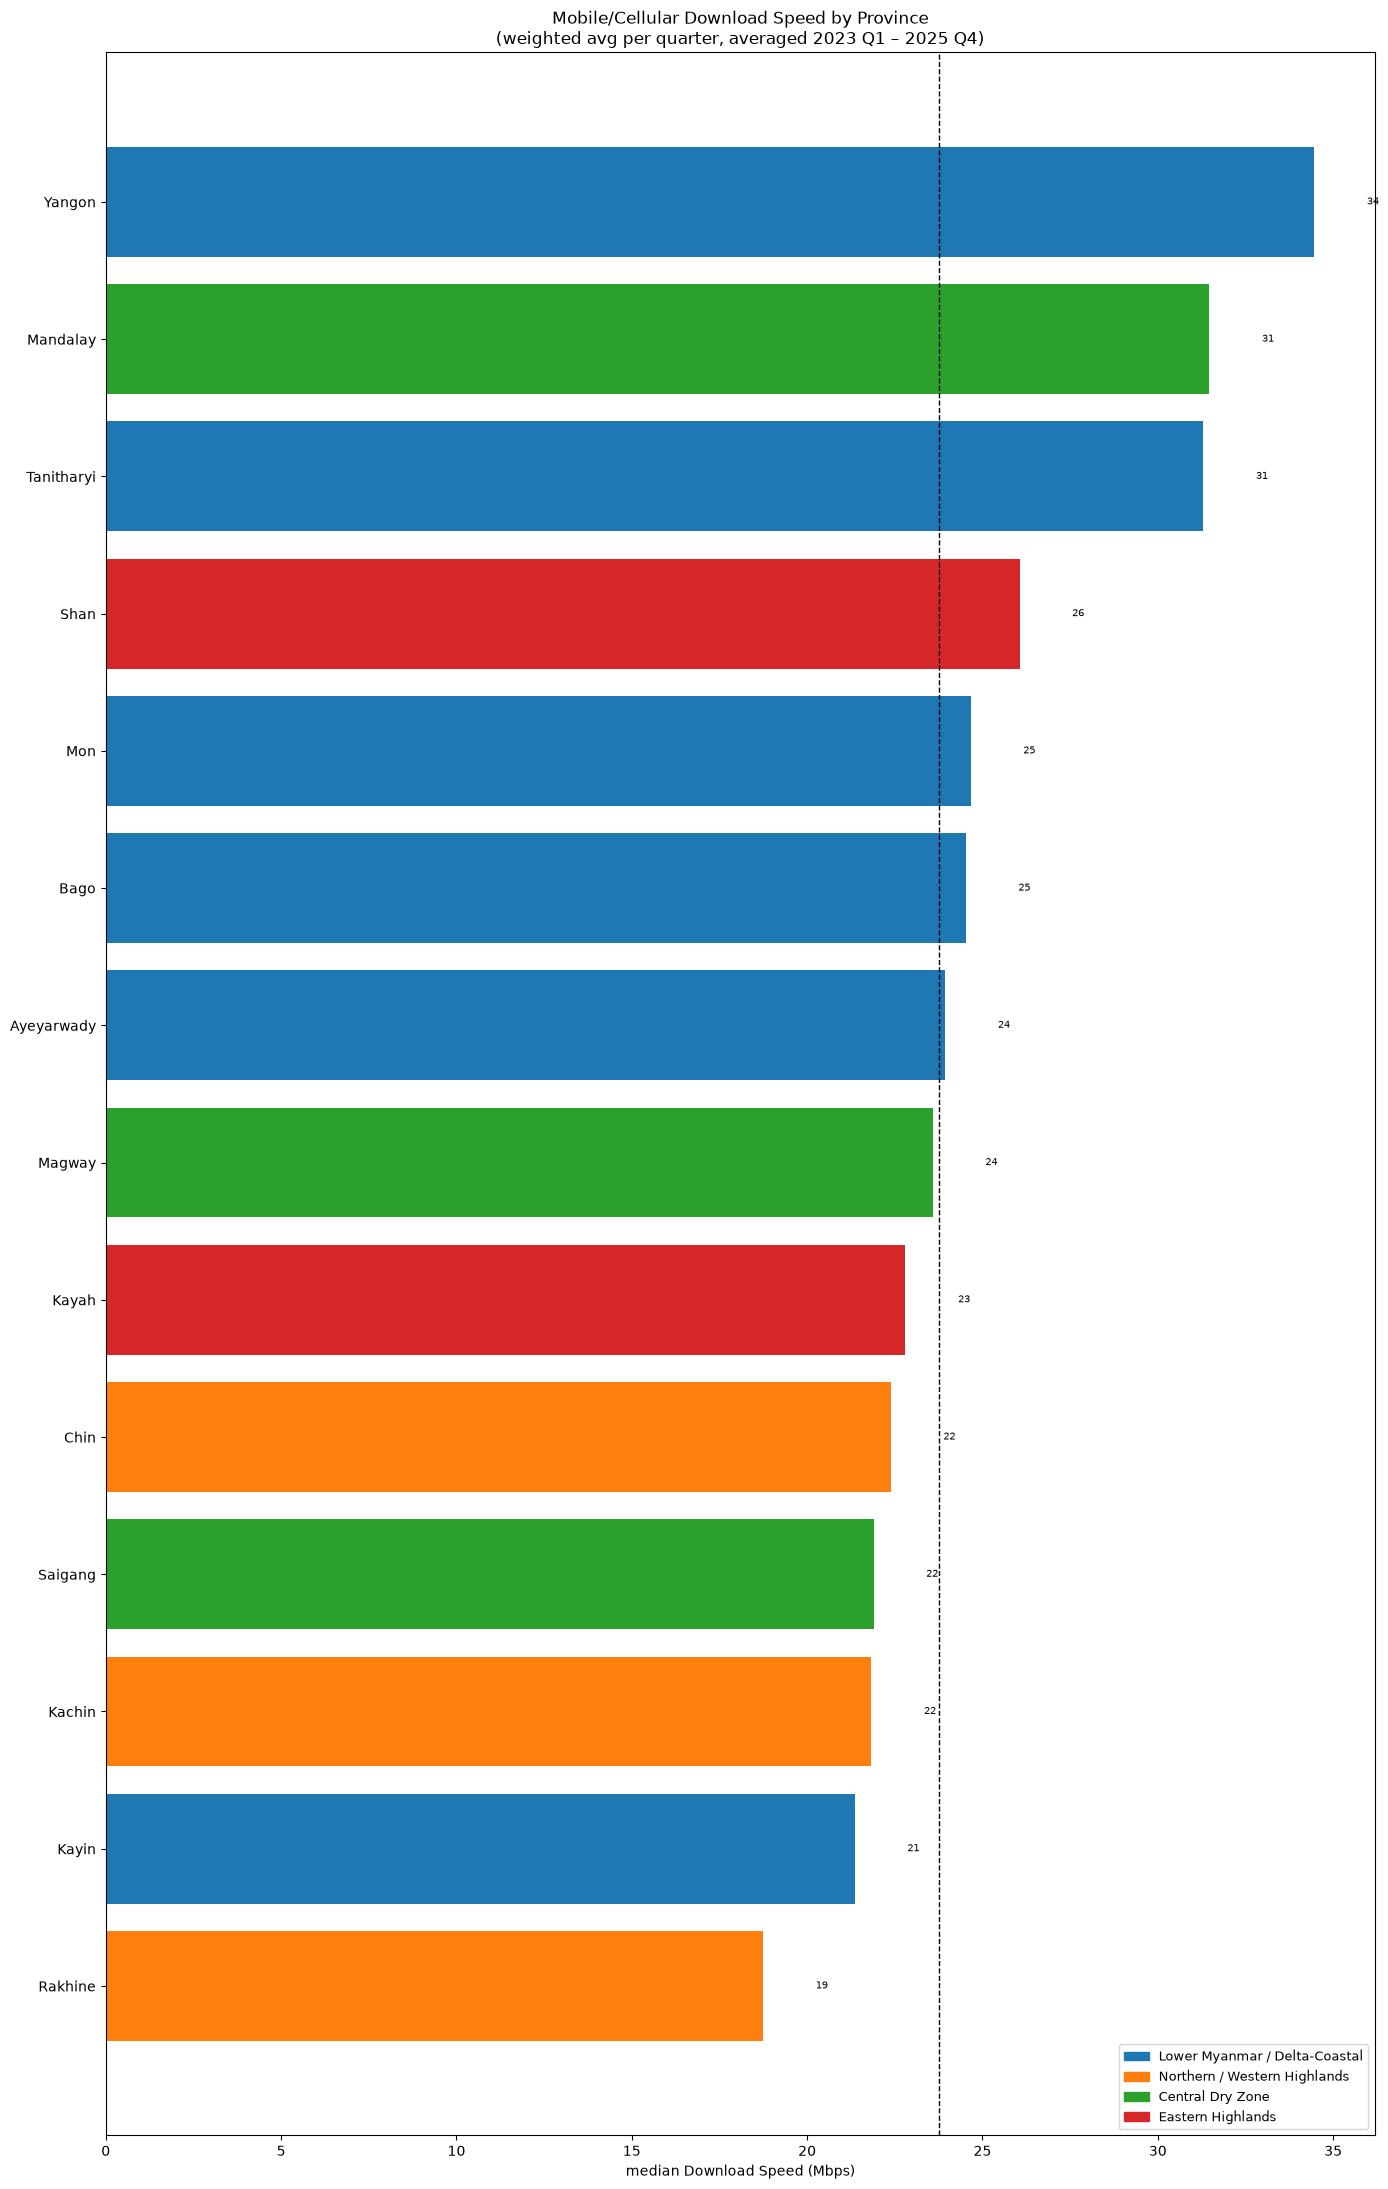

In [44]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

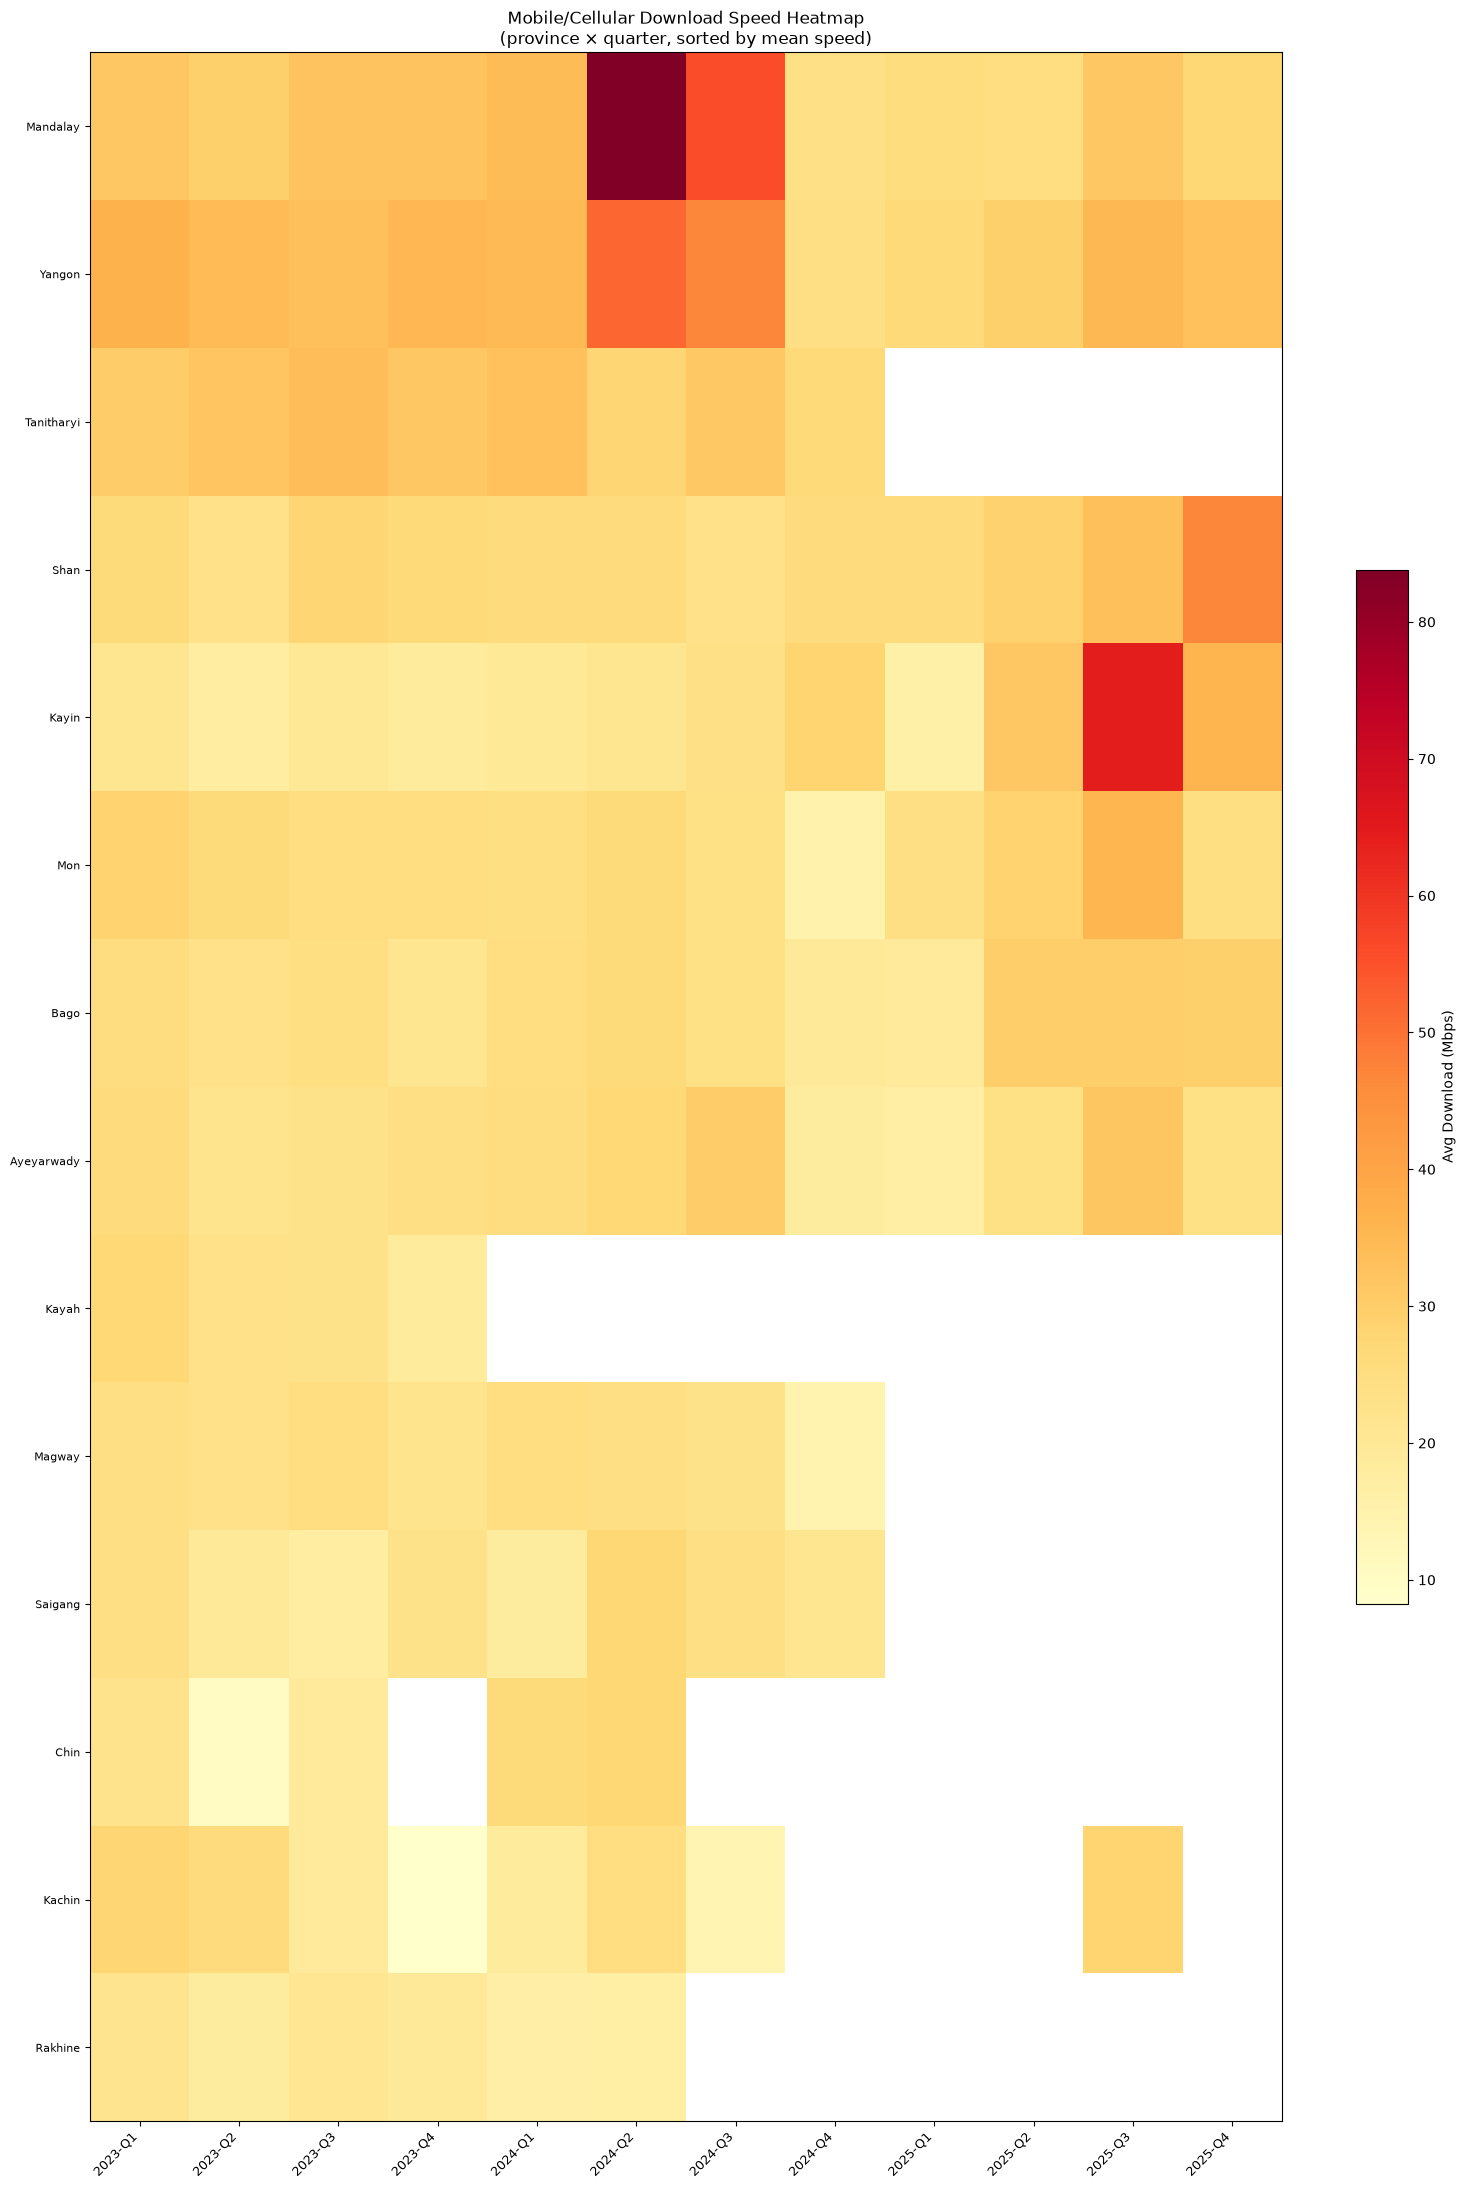

In [45]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

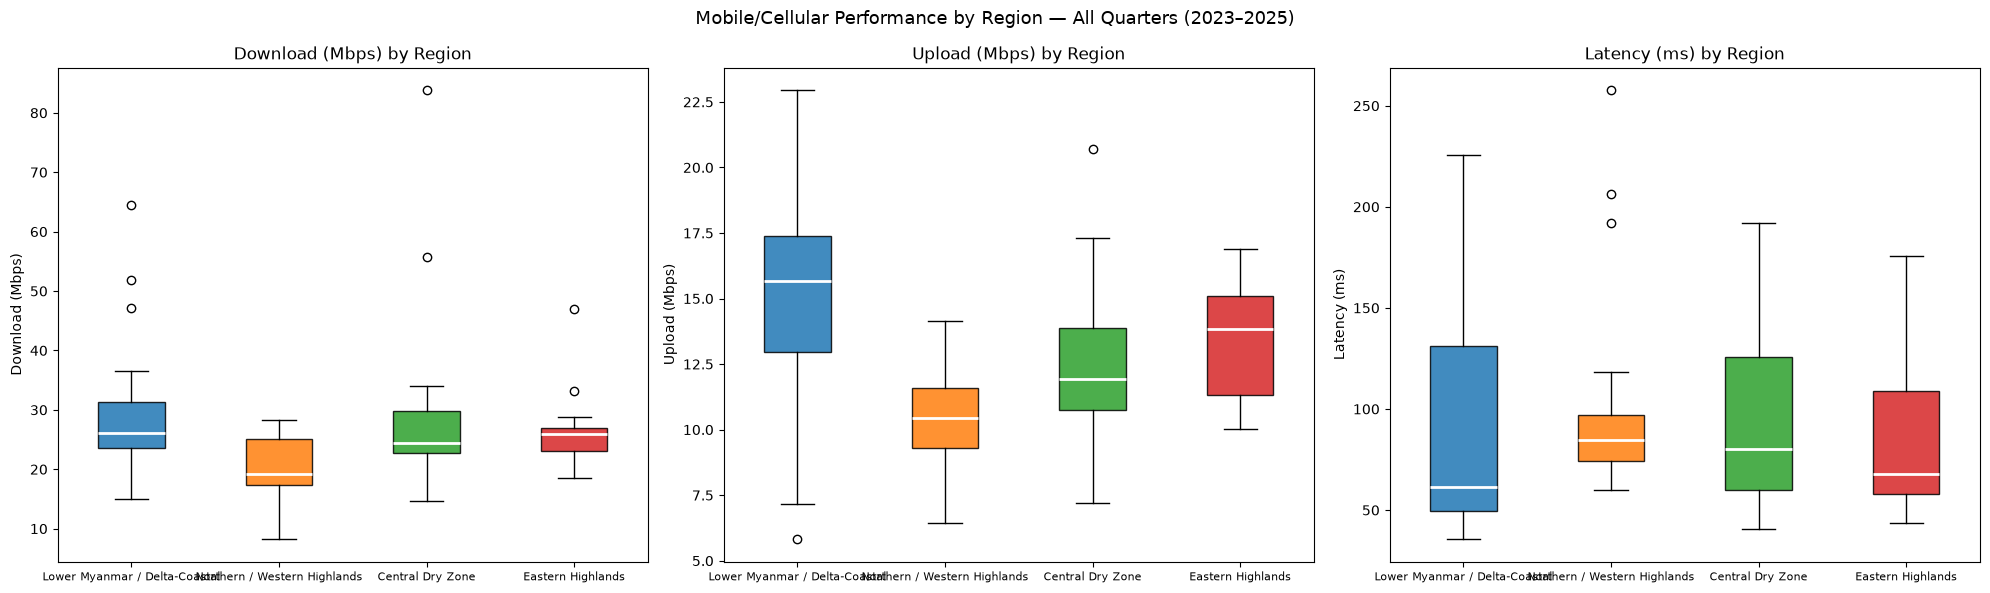

In [46]:
region_order = ['Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands', 'Central Dry Zone', 'Eastern Highlands']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

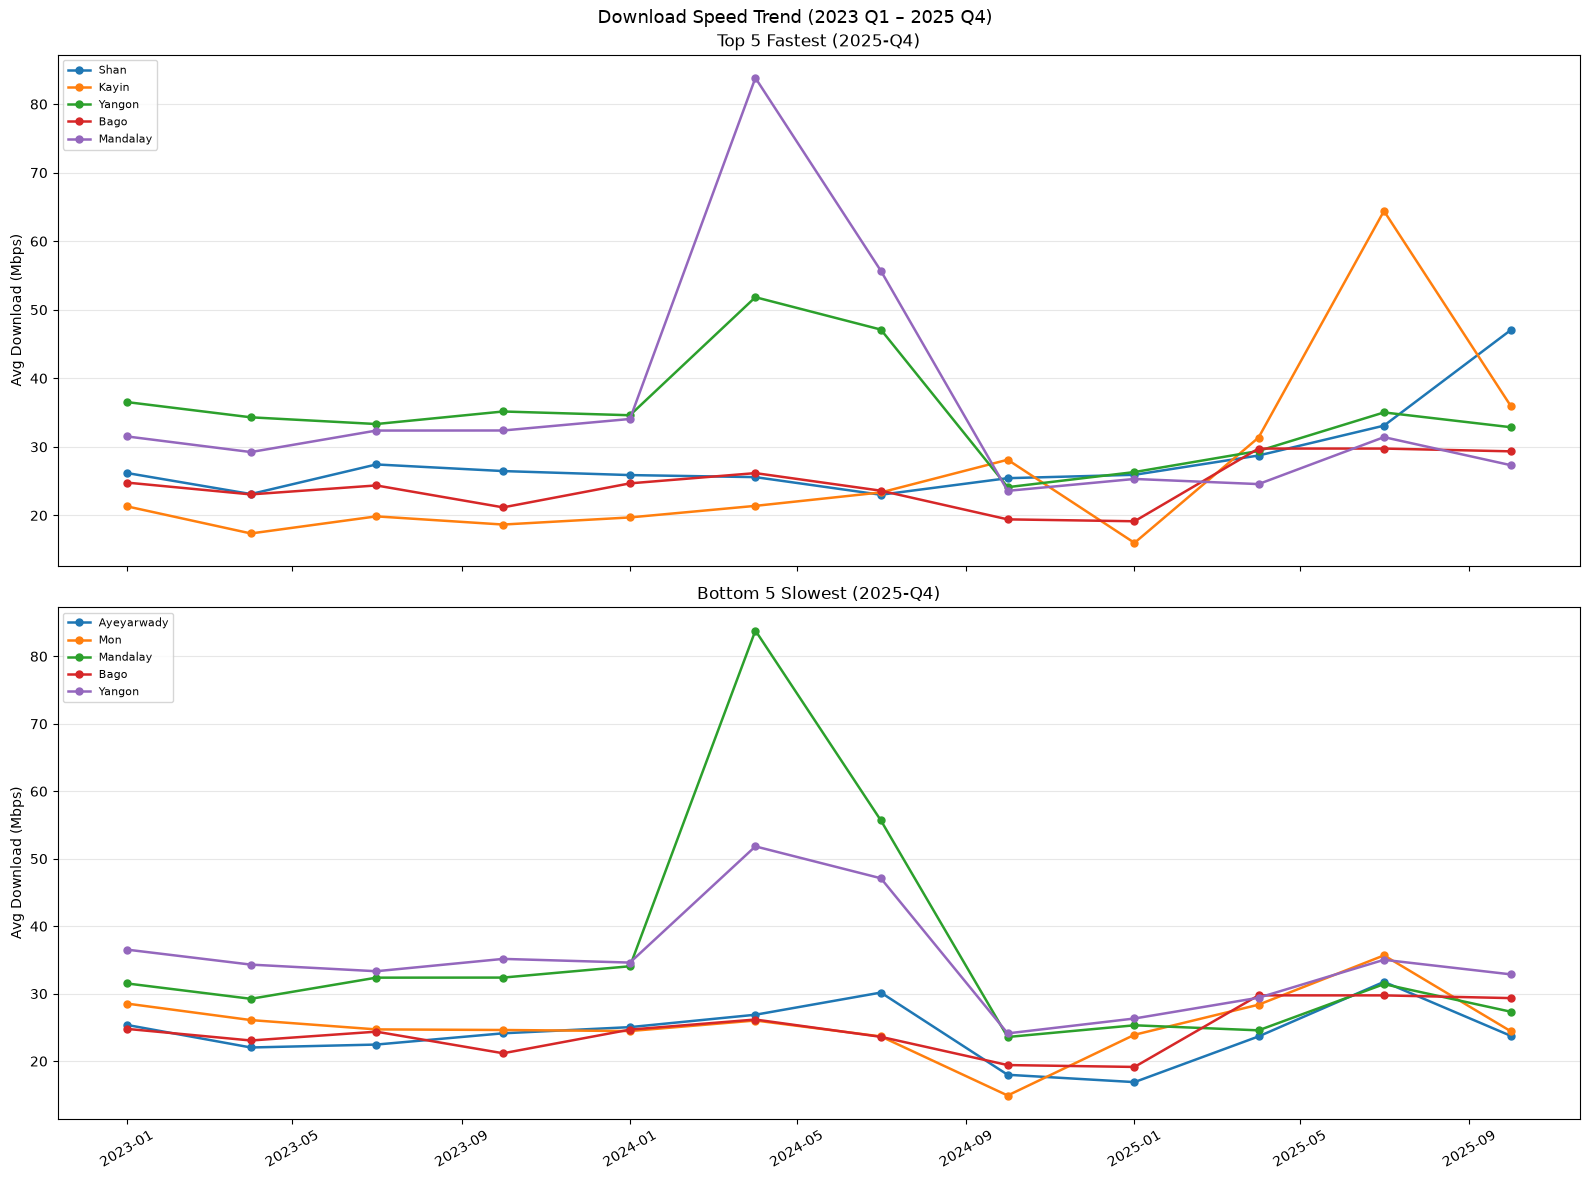

In [47]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

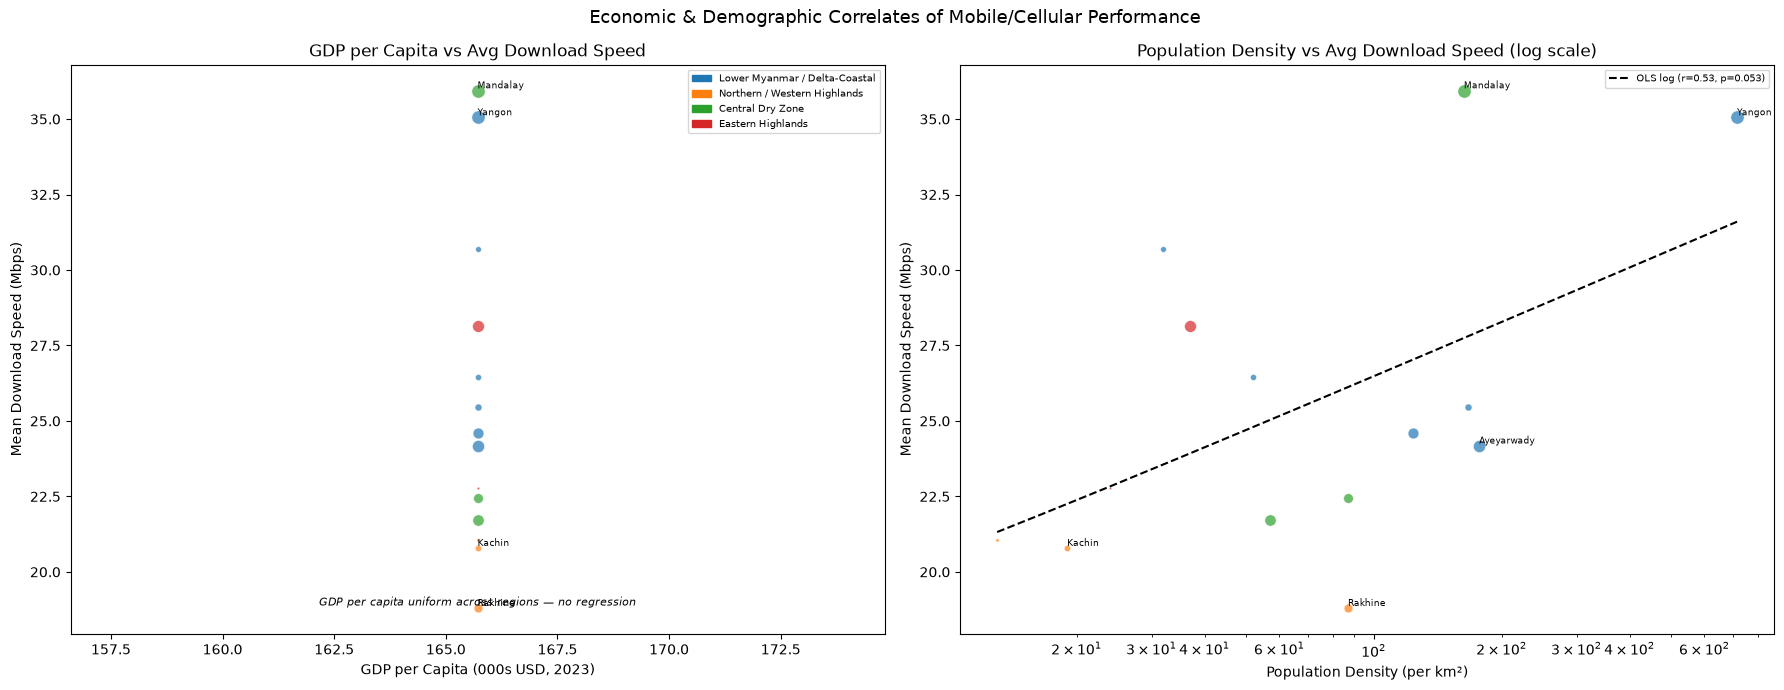

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.527  p=0.0529


In [48]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

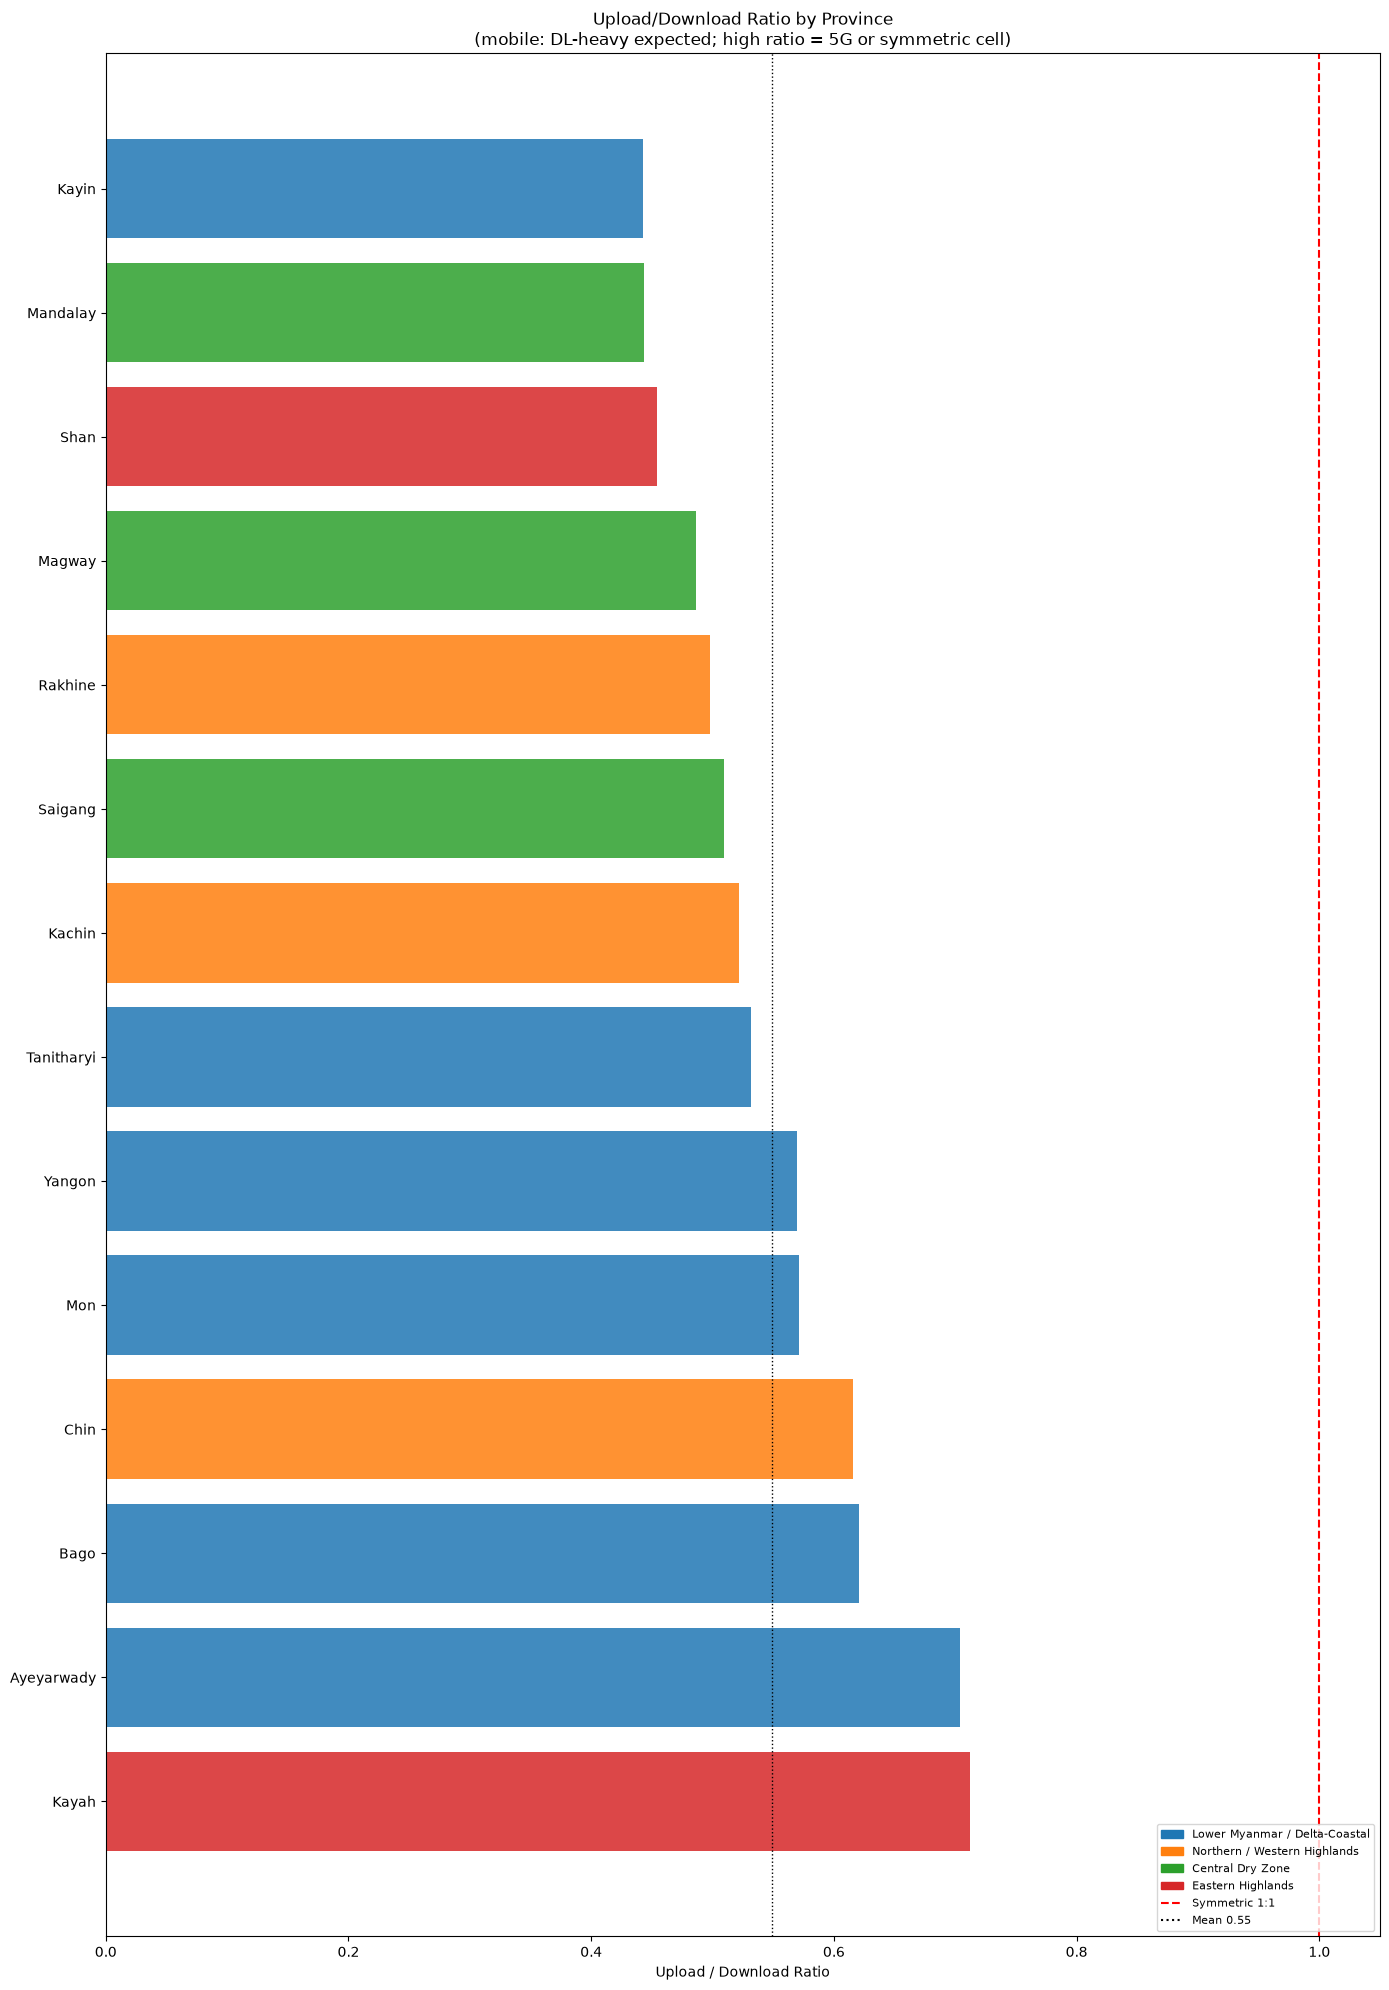

Provinces with UL/DL ratio > 0.5 (9):
      name                        region  ul_dl_ratio
     Kayah             Eastern Highlands     0.712545
Ayeyarwady Lower Myanmar / Delta-Coastal     0.704088
      Bago Lower Myanmar / Delta-Coastal     0.620596
      Chin  Northern / Western Highlands     0.615946
       Mon Lower Myanmar / Delta-Coastal     0.571325
    Yangon Lower Myanmar / Delta-Coastal     0.569276
Tanitharyi Lower Myanmar / Delta-Coastal     0.531845
    Kachin  Northern / Western Highlands     0.522171
   Saigang              Central Dry Zone     0.509224


In [49]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [50]:
# Per-province summary stats used by later sections (UL/DL ratio, tier median)

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [51]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

      name                        region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
  Mandalay              Central Dry Zone              1    35.94    14.66     94.02         0.44     3268.08                 165710.4
    Yangon Lower Myanmar / Delta-Coastal              1    35.05    19.53     82.51         0.57     6706.83                 165710.4
Tanitharyi Lower Myanmar / Delta-Coastal              4    30.70    16.33     74.47         0.53      738.88                 165710.4
      Shan             Eastern Highlands              3    28.16    12.51     93.00         0.45     2485.92                 165710.4
     Kayin Lower Myanmar / Delta-Coastal              3    26.46    10.30     59.06         0.44     1171.75                 165710.4
       Mon Lower Myanmar / Delta-Coastal              1    25.45    14.13     96.13         0.57     1001.25                 165710.4
      Bago Lower Myanmar / Delta-Coastal              2    24.

### 13. UL/DL Symmetry — Mobile Network Quality Indicator

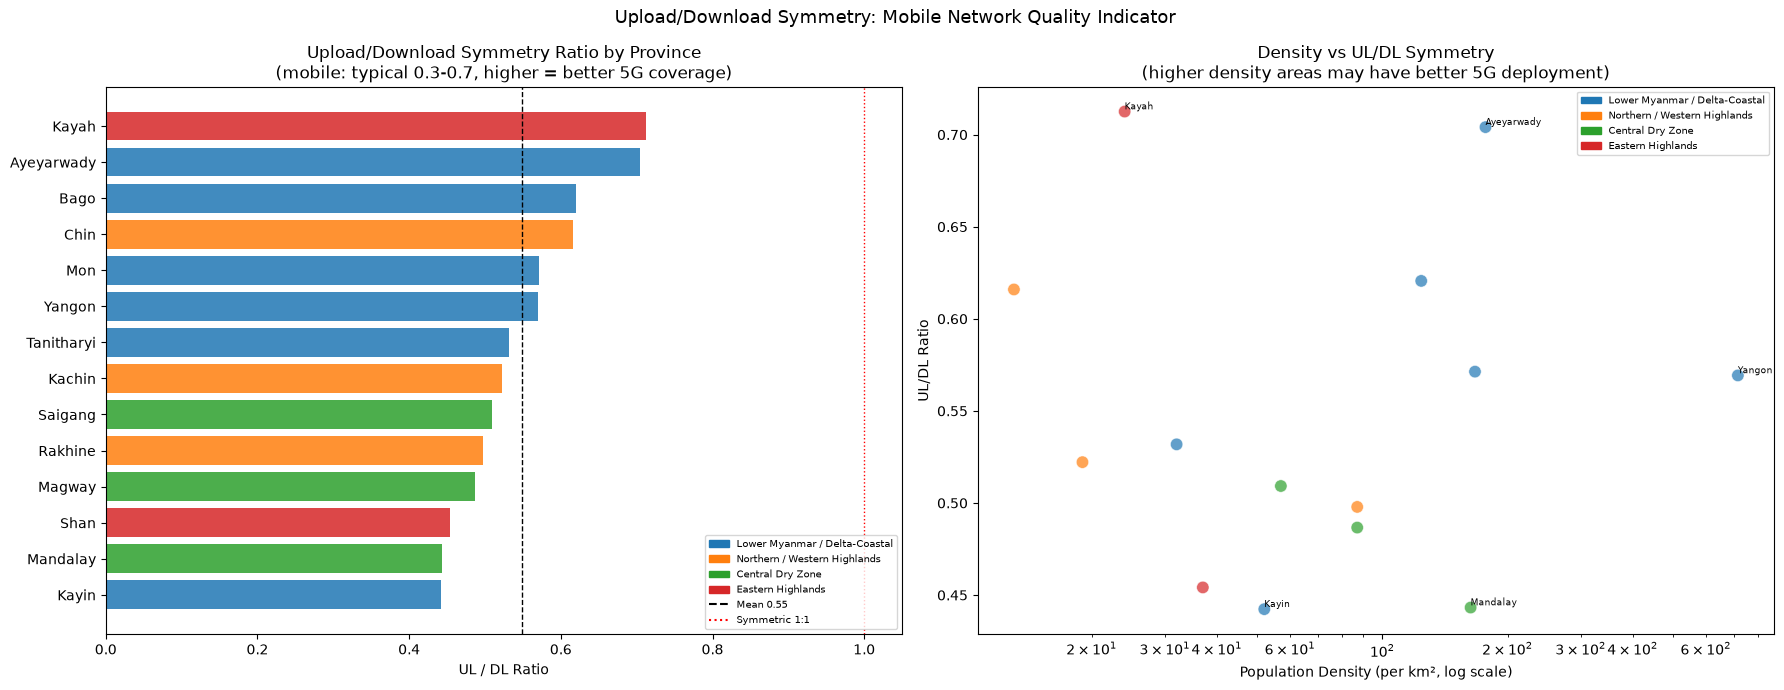

Provinces ratio > 0.5 (relatively symmetric mobile): 9 out of 14
Lower Myanmar / Delta-Coastal mean ratio: 0.573
Lower Myanmar / Delta-Coastal mean ratio: 0.573


In [52]:
# Mobile UL/DL ratio: typically 0.3-0.7 (DL-heavy by design)
# 5G NR can be more symmetric; high ratio may indicate 5G coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(mobile: typical 0.3-0.7, higher = better 5G coverage)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1) or row['mean_dl'] > prov_mean['mean_dl'].quantile(0.9):
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\n(higher density areas may have better 5G deployment)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Mobile Network Quality Indicator', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.5 (relatively symmetric mobile): {(prov_mean['mean_ratio'] > 0.5).sum()} out of {len(prov_mean)}")
print(f"{_top_region} mean ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].mean():.3f}")
print(f"{_bot_region} mean ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].mean():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

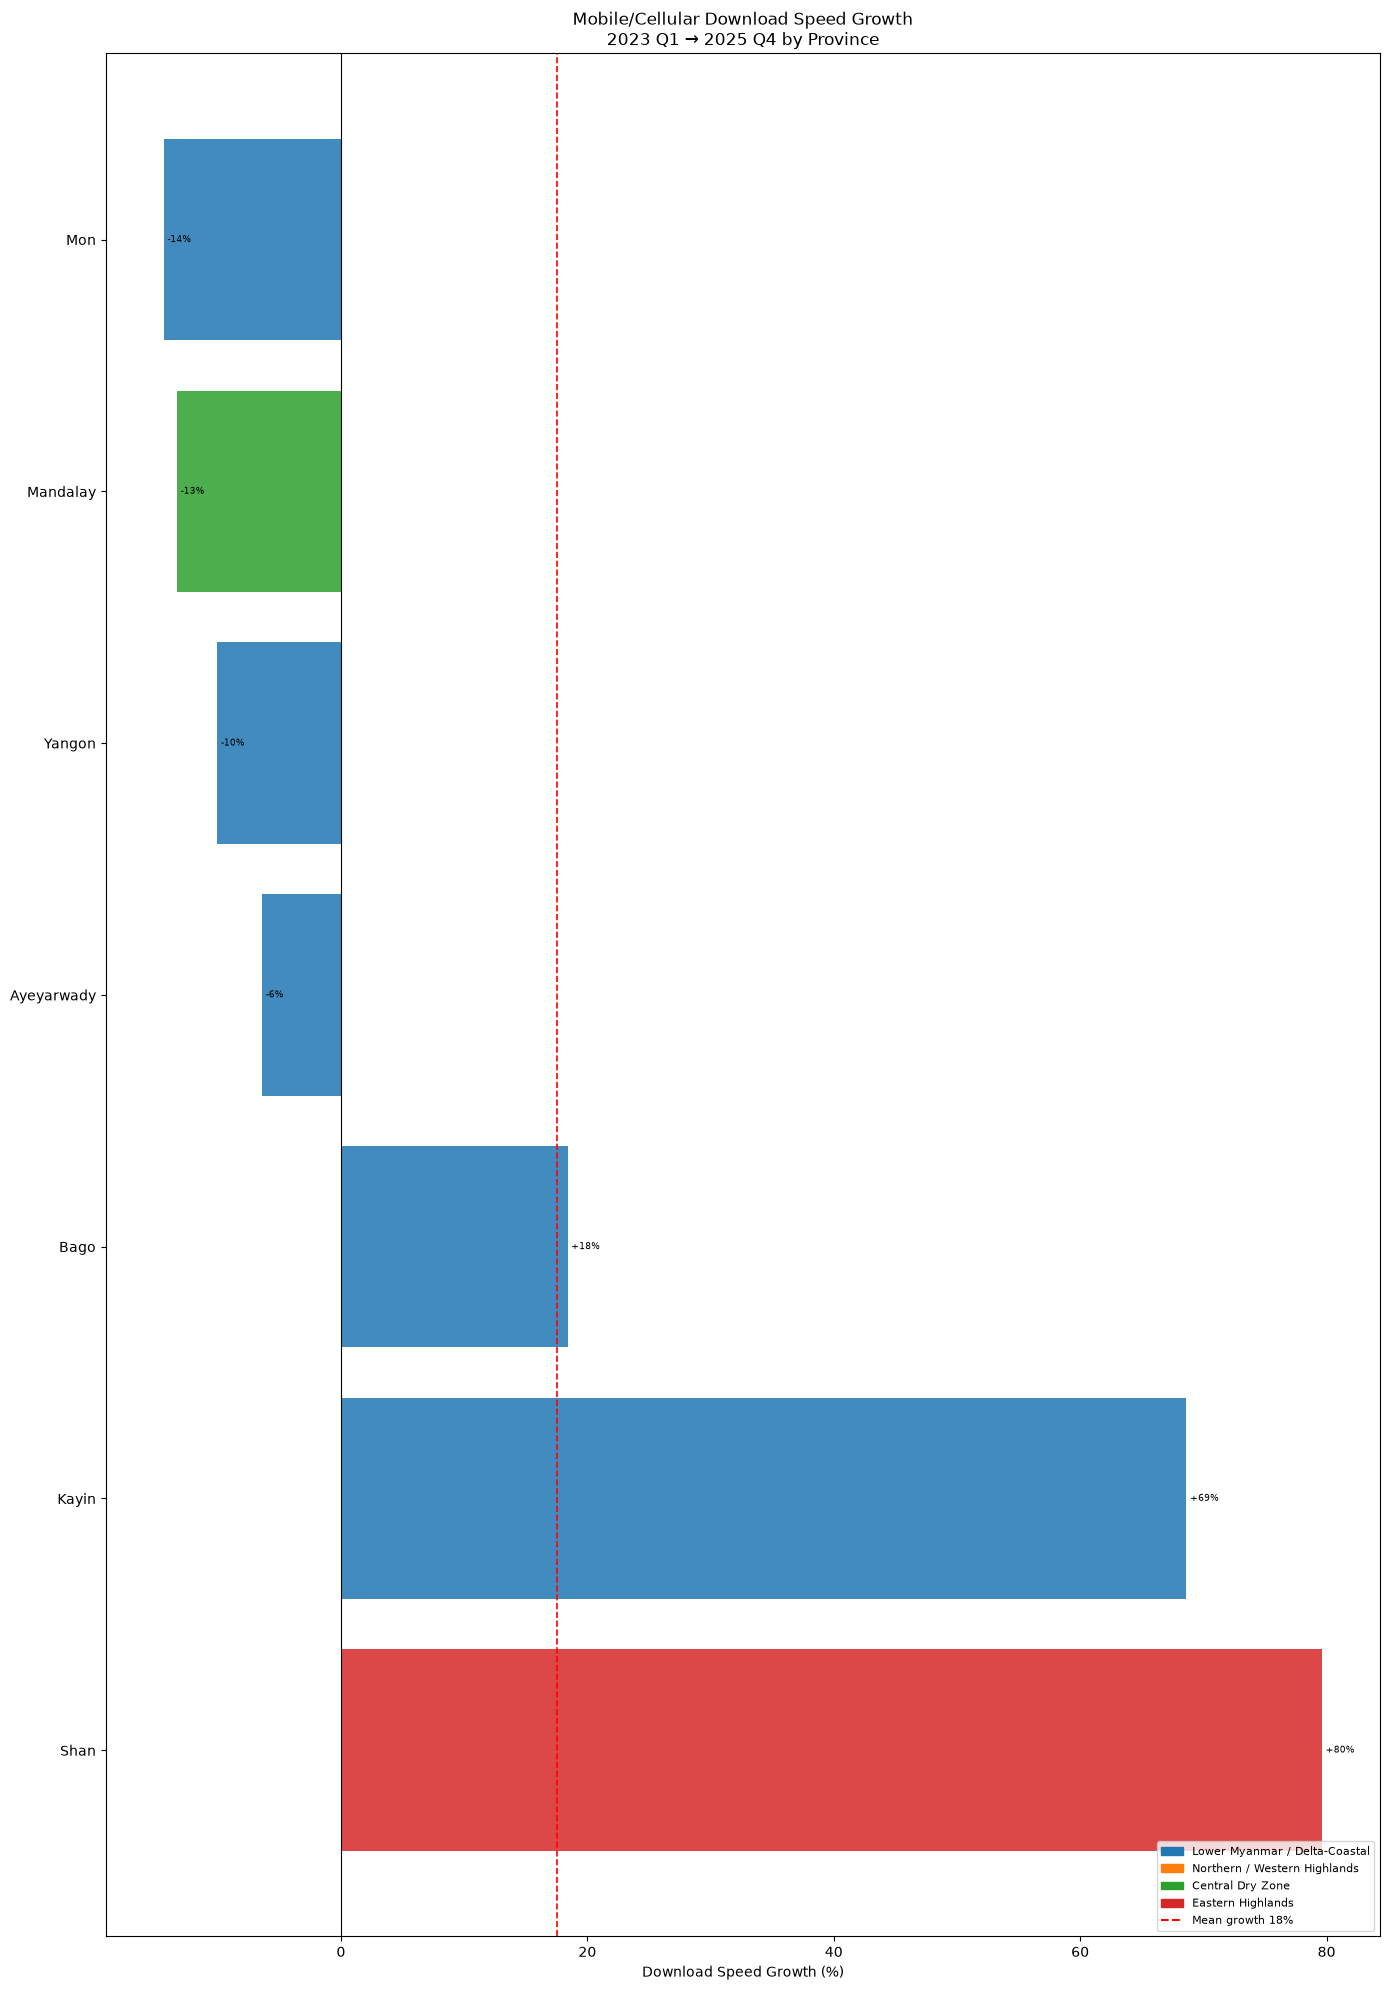

Top 10 fastest growing provinces:
      name                        region  internet_tier  pct_growth
      Shan             Eastern Highlands              3   79.634187
     Kayin Lower Myanmar / Delta-Coastal              3   68.627041
      Bago Lower Myanmar / Delta-Coastal              2   18.391121
Ayeyarwady Lower Myanmar / Delta-Coastal              1   -6.397074
    Yangon Lower Myanmar / Delta-Coastal              1  -10.042159
  Mandalay              Central Dry Zone              1  -13.307154
       Mon Lower Myanmar / Delta-Coastal              1  -14.386436

Bottom 5 (slowest growth or decline):
      name                        region  internet_tier  pct_growth
       Mon Lower Myanmar / Delta-Coastal              1  -14.386436
  Mandalay              Central Dry Zone              1  -13.307154
    Yangon Lower Myanmar / Delta-Coastal              1  -10.042159
Ayeyarwady Lower Myanmar / Delta-Coastal              1   -6.397074
      Bago Lower Myanmar / Delta-Coastal   

In [53]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/myanmar/mobile/20_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 16. EDA Key Findings Summary

## Key Findings from EDA

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [54]:
# ── Export Ookla Mobile quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_mobile_myanmar_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 131 rows → ../../data/exports/ookla_mobile_myanmar_province_quarterly.csv
     province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable                         region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Ayeyarwady  2023-Q1  2023        1   25.374630   17.676278      52.694159       3407.0   1167.0         True  Lower Myanmar / Delta-Coastal              1   6184829                 165710.4              177
1        Bago  2023-Q1  2023        1   24.787642   16.217782      51.312830       2650.0   1016.0         True  Lower Myanmar / Delta-Coastal              2   4867373                 165710.4              124
2        Chin  2023-Q1  2023        1   22.385922   11.584376      60.021277        141.0     31.0         True   Northern / Western Highlands              4    478801                 165710.4               13
